## Import Packages

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

import quandl

from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import scipy
from scipy.stats import ttest_ind, f_oneway

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Import Ensemble models
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor 

from sklearn.metrics import classification_report, accuracy_score
import cvxpy as cp
import re

from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from matplotlib import cm
from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from statsmodels.tsa.stattools import ccf
from statsmodels.tsa.stattools import coint

import gym
from gym import Env, spaces

import seaborn


### Preface
#### The general description and implementation of the strategy is listed below. It will also help in deciphering the general organization and flow of this notebook.
##### <b> I. Data collection, enrichment and feature analyses </b>
###### 1. Pull NASDAQ100 Stocks
###### 2. Feature generation function
###### 3. Define features for each stock
###### 4. Feature Selection
  ###### 4.1 Correlation Analysis
  ###### 4.2 Statistical Tests like ANOVA
###### 5. Train-Test splitting & normalization
###### 6. PCA Analysis
###### 7. Interpret Principal Components
###### 8. Get feature loadings
###### 9. Top features of each principal component
###### 10. Plot loadings of top 2 components
###### 11. Plot top features of each principal component 

##### <b> II. Stock Selection - first reduction using ensemble models </b>
###### This is an attempt to use data science tools at our disposal. We use the top identified Principal Components in ensemble models, test multiple models and select the best one to determine the most promising stocks
###### 1. Model Selection (Random Forest, Gradient Boosting, Extra Trees, AdaBoost, XGBoost)
###### 2. Stock selection with high growth points
###### 3. Stock selection with high growth points
###### This is the critical pivot point and this is where the strategy formulates. We split the portfolio into 2 parts. Portfolio B: Statistical Arbitrage and Pair Trading and Portfolio B: Momentum-Based Trading. 50% of all our stocks make up Portfolio A. The exact same spread makes up Portfolio B.

##### <b> III. Statistical Arbitrage </b>
###### 1. Data preparation
###### 2. Identify cointegrated pairs
###### 3. Build a trading strategy based on the identified pairs
###### 4. Backtest the strategy
###### 5. Build definitive trading signals

##### <b> IV. Momentum Strategy, Backtesting and Stock Selection 2nd pass </b>
###### 1. Cluster identification
###### 2. Cluster compositiona and visualization
###### 2. Compare with NASDAQ-100 performance
###### 3. Backtest the metrics and strategy

##### <b> V. Reinforcement Learning </b>
###### 1. Create a custom trading environment
###### 2. Implement Q-learning
###### 3. Train the model
###### 4. Evaluate the model


## I. Data Collection, enrichment and feature analyses

### 1. We start by using the NASDAQ-100 as our baseline of stocks

We pull the list from wikipedia and ensure that we parse out non-ticker content. We choose NASDAQ-100 over S&P-500 as the former has consistently outperformed the latter for the past 16 years save for one year of Covid.

In [7]:
# URL for NASDAQ-100 constituents
nasdaq_100_url = 'https://en.wikipedia.org/wiki/NASDAQ-100'

# Read all the tables from the Wikipedia page
tables = pd.read_html(nasdaq_100_url)

# Find the table containing NASDAQ-100 stocks
for table in tables:
    if 'Ticker' in table.columns or 'Company' in table.columns:
        nasdaq_100_table = table
        break

# Extract the 'Ticker' column and convert it to a list
nasdaq_100_stocks = nasdaq_100_table['Ticker'].tolist()

# Print the list of NASDAQ-100 stocks
print(nasdaq_100_stocks)

['ADBE', 'ABNB', 'GOOGL', 'GOOG', 'AMZN', 'AMD', 'AEP', 'AMGN', 'ADI', 'ANSS', 'AAPL', 'AMAT', 'ARM', 'ASML', 'AZN', 'TEAM', 'ADSK', 'ADP', 'BKR', 'BIIB', 'BKNG', 'AVGO', 'CDNS', 'CDW', 'CHTR', 'CTAS', 'CSCO', 'CCEP', 'CTSH', 'CMCSA', 'CEG', 'CPRT', 'CSGP', 'COST', 'CRWD', 'CSX', 'DDOG', 'DXCM', 'FANG', 'DLTR', 'DASH', 'EA', 'EXC', 'FAST', 'FTNT', 'GEHC', 'GILD', 'GFS', 'HON', 'IDXX', 'ILMN', 'INTC', 'INTU', 'ISRG', 'KDP', 'KLAC', 'KHC', 'LRCX', 'LIN', 'LULU', 'MAR', 'MRVL', 'MELI', 'META', 'MCHP', 'MU', 'MSFT', 'MRNA', 'MDLZ', 'MDB', 'MNST', 'NFLX', 'NVDA', 'NXPI', 'ORLY', 'ODFL', 'ON', 'PCAR', 'PANW', 'PAYX', 'PYPL', 'PDD', 'PEP', 'QCOM', 'REGN', 'ROP', 'ROST', 'SBUX', 'SMCI', 'SNPS', 'TTWO', 'TMUS', 'TSLA', 'TXN', 'TTD', 'VRSK', 'VRTX', 'WBD', 'WDAY', 'XEL', 'ZS']


Now we make the end date dynamic and set to current_day so as to pull each day's available data. We connect to yahoo finance and pull all available information for the nasdaq 100 stocks

In [9]:
tickers = nasdaq_100_stocks
start_date = '2020-01-01'

#Store today's date in end_date
# Get the current date
now = datetime.now()

# Get the first date of the current month
end_date = now.replace(day=1).strftime('%Y-%m-%d')

data = yf.download(tickers, start=start_date, end=end_date)

[*********************100%%**********************]  101 of 101 completed


In [10]:
data.head(5)

Price       Adj Close                                                       \
Ticker           AAPL ABNB        ADBE         ADI         ADP        ADSK   
Date                                                                         
2020-01-02  72.960464  NaN  334.429993  110.811882  154.778061  187.830002   
2020-01-03  72.251144  NaN  331.809998  108.861168  154.450928  184.949997   
2020-01-06  72.826859  NaN  333.709991  107.582191  154.659943  187.119995   
2020-01-07  72.484352  NaN  333.390015  110.029762  152.787933  187.500000   
2020-01-08  73.650337  NaN  337.869995  111.023506  154.223740  189.949997   

Price                                                    ...     Volume  \
Ticker            AEP       AMAT        AMD        AMGN  ...       TSLA   
Date                                                     ...              
2020-01-02  78.744621  59.614624  49.099998  209.199463  ...  142981500   
2020-01-03  78.660385  58.665775  48.599998  207.779251  ...  266677500   
2020-01-06  78.921577  57.400635  48.389999  209.373734  ...  151995000   
2020-01-07  78.938416  59.058739  48.250000  207.404587  ...  268231500   
2020-01-08  78.702499  59.020393  47.830002  207.561432  ...  467164500   

Price                                                                       \
Ticker           TTD     TTWO      TXN     VRSK     VRTX      WBD     WDAY   
Date                                                                         
2020-01-02  22197000  1114200  4614000   845100  1334300  3249300  1503000   
2020-01-03  13736000   729100  4057200   876900   943400  3599600  1276300   
2020-01-06  18238000  1678700  4345400   656200  1436600  2416900  1623300   
2020-01-07  21999000  1179300  7184100  1514700  1027700  3102000  2404100   
2020-01-08  20523000  1665900  3546900   773100  1802600  3674100  2819900   

Price                         
Ticker          XEL       ZS  
Date                          
2020-01-02  2915400  1377200  
2020-01-03  2422500  1165200  
2020-01-06  2217100  1534600  
2020-01-07  1861100  1714900  
2020-01-08  4828900  3232500  

[5 rows x 606 columns]

### 2. Feature Generation function

This function takes a DataFrame containing stock data and adds various technical indicators to it. The various columns added are
1. Returns: Calculates the daily percentage change in the adjusted closing price.
2. Moving Averages: Computes 20-day and 50-day moving averages of the adjusted closing price.
3. Volatility: Measures the 20-day rolling standard deviation of returns (a measure of volatility).
4. Bollinger Bands: Calculates the upper and lower Bollinger Bands based on a 20-day moving average and standard deviation.
5. Relative Strength Index (RSI): Evaluates the momentum by comparing recent gains to recent losses over a 14-day period.
6. MACD (Moving Average Convergence Divergence): Calculates the MACD, which is the difference between 12-day and 26-day exponential moving averages, and a signal line based on the MACD.
7. On-Balance Volume (OBV): Tracks the cumulative buying and selling pressure using volume and price movements.
8. Average True Range (ATR): Measures market volatility by averaging the true range of prices over 14 days.
9. Williams %R: Identifies overbought or oversold conditions by comparing the current price to the highest and lowest prices over a 14-day period.
The function returns the modified DataFrame with these new columns.

In [13]:
def calculate_technical_indicators(df):
    # Calculate returns
    df['Return'] = df['Adj Close'].pct_change() * 100
    
    # Calculate moving averages
    df['20d_MA'] = df['Adj Close'].rolling(window=20).mean()
    df['50d_MA'] = df['Adj Close'].rolling(window=50).mean()
    
    # Calculate volatility
    df['20d_Volatility'] = df['Return'].rolling(window=20).std()
    
    # Calculate Bollinger Bands
    df['20d_MA'] = df['Adj Close'].rolling(window=20).mean()
    df['20d_SD'] = df['Adj Close'].rolling(window=20).std()
    df['Upper_BB'] = df['20d_MA'] + (df['20d_SD']*2)
    df['Lower_BB'] = df['20d_MA'] - (df['20d_SD']*2)
    
    # Calculate RSI
    delta = df['Adj Close'].diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    RS = gain / loss
    df['RSI'] = 100 - (100 / (1 + RS))
    
    # Calculate MACD
    df['12d_EMA'] = df['Adj Close'].ewm(span=12, adjust=False).mean()
    df['26d_EMA'] = df['Adj Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['12d_EMA'] - df['26d_EMA']
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()
    
    # Calculate OBV
    df['OBV'] = (np.sign(df['Adj Close'].diff()) * df['Volume']).fillna(0).cumsum()
    
    # Calculate ATR
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Adj Close'].shift())
    low_close = np.abs(df['Low'] - df['Adj Close'].shift())
    df['TR'] = high_low.combine(high_close, np.maximum).combine(low_close, np.maximum)
    df['ATR'] = df['TR'].rolling(window=14).mean()
    
    # Calculate Williams %R
    highest_high = df['High'].rolling(window=14).max()
    lowest_low = df['Low'].rolling(window=14).min()
    df['Williams_%R'] = (highest_high - df['Adj Close']) / (highest_high - lowest_low) * -100
    
    return df

### 3. Combine Features for Each Ticker

This code initializes and builds a features DataFrame by calculating technical indicators for a list of verified NASDAQ100 stock tickers. 
It prepares a comprehensive dataset containing calculated technical indicators for multiple stocks, with each stock's data 
neatly organized in the features DataFrame.

In [16]:
#Initialize the features dataframe. Declare as a global variable
global features  # Use the global features DataFrame
features = pd.DataFrame()

# Use verified tickers from data columns
# Check if columns are MultiIndex. If they are, it extracts the unique tickers from the second level. 
if isinstance(data.columns, pd.MultiIndex):
    # Use verified tickers from the second level of the MultiIndex
    verified_tickers = data.columns.get_level_values(1).unique()
#If not, it uses the single-level index of column names.
else:
    # Handle the case where data.columns is not a MultiIndex
    print("The columns are not MultiIndex. Verifying tickers using single-level Index.")
    verified_tickers = data.columns.unique()


#Calculate Technical Indicators: For each verified ticker, the code extracts the stock data, computes various technical indicators 
#using the calculate_technical_indicators function and renames the columns to include the ticker symbol as a prefix.

for ticker in verified_tickers:
    stock_data = data.xs(ticker, level=1, axis=1).copy()
    stock_data = calculate_technical_indicators(stock_data)
    stock_data = stock_data[['Return', '20d_MA', '50d_MA', '20d_Volatility', 'Upper_BB', 'Lower_BB', 'RSI', 'MACD', 'Signal_Line', 'OBV', 'ATR', 'Williams_%R']]
    stock_data.columns = [f'{ticker}_{col}' for col in stock_data.columns]
    if features.empty:
        features = stock_data
    else:
        features = features.join(stock_data)

#Drop any rows with missing values and displays the first few rows of the features DataFrame.
features.dropna(inplace=True)
features.head()


,AAPL_Return,AAPL_20d_MA,AAPL_50d_MA,AAPL_20d_Volatility,AAPL_Upper_BB,AAPL_Lower_BB,AAPL_RSI,AAPL_MACD,AAPL_Signal_Line,AAPL_OBV,...,ZS_50d_MA,ZS_20d_Volatility,ZS_Upper_BB,ZS_Lower_BB,ZS_RSI,ZS_MACD,ZS_Signal_Line,ZS_OBV,ZS_ATR,ZS_Williams_%R
Date,,,,,,,,,,,,,,,,,,,,,
2023-11-22,0.351442,180.904463,177.125642,1.139423,197.340224,164.468702,82.301528,4.221564,3.148048,1.815456e+09,...,165.144999,2.010029,200.124393,145.543604,83.126170,7.867349,5.937916,197878200.0,6.309218,-7.503963
2023-11-24,-0.700430,182.066381,177.414106,0.944044,197.382392,166.750370,80.729554,4.151080,3.348655,1.791408e+09,...,165.822199,1.892757,202.064418,147.451579,82.096544,8.108102,6.371953,198853600.0,5.959933,-3.367210
2023-11-27,-0.094756,183.153085,177.713523,0.958216,197.163043,169.143126,77.463929,4.034230,3.485770,1.750855e+09,...,166.538399,1.911752,203.191198,150.078800,81.585951,8.110196,6.719601,192535800.0,5.772791,-10.323435
2023-11-28,0.321408,184.167117,177.966140,0.949049,196.933108,171.401125,74.944137,3.945239,3.577664,1.789271e+09,...,167.320999,1.908634,204.379808,152.594191,78.765360,8.174170,7.010515,203549200.0,5.928505,-4.574430
2023-11-29,-0.540968,185.105878,178.176299,0.979567,196.162328,174.049427,69.050093,3.748608,3.611852,1.746257e+09,...,168.216799,1.960813,206.353276,154.735723,80.475725,8.608973,7.330207,209669500.0,6.561433,-20.164564


### 4. Feature Selection

#### 4.1 Correlation Analysis

This code calculates the correlation of various features with Nvidia's stock return and visualizes it:
The corrwith function computes the correlation between every feature in the features DataFrame and Nvidia's return (NVDA_Return).

The results are converted into a DataFrame and visualized using a heatmap.
The heatmap uses a color gradient (coolwarm) to represent the correlation values, with annotations showing the exact values.
This visualization helps to quickly identify which features are most strongly correlated with Nvidia's stock returns.

In [20]:
# First Visualize the column names in the features dataframe
print(features.columns)

Index(['AAPL_Return', 'AAPL_20d_MA', 'AAPL_50d_MA', 'AAPL_20d_Volatility',
       'AAPL_Upper_BB', 'AAPL_Lower_BB', 'AAPL_RSI', 'AAPL_MACD',
       'AAPL_Signal_Line', 'AAPL_OBV',
       ...
       'ZS_50d_MA', 'ZS_20d_Volatility', 'ZS_Upper_BB', 'ZS_Lower_BB',
       'ZS_RSI', 'ZS_MACD', 'ZS_Signal_Line', 'ZS_OBV', 'ZS_ATR',
       'ZS_Williams_%R'],
      dtype='object', length=1212)


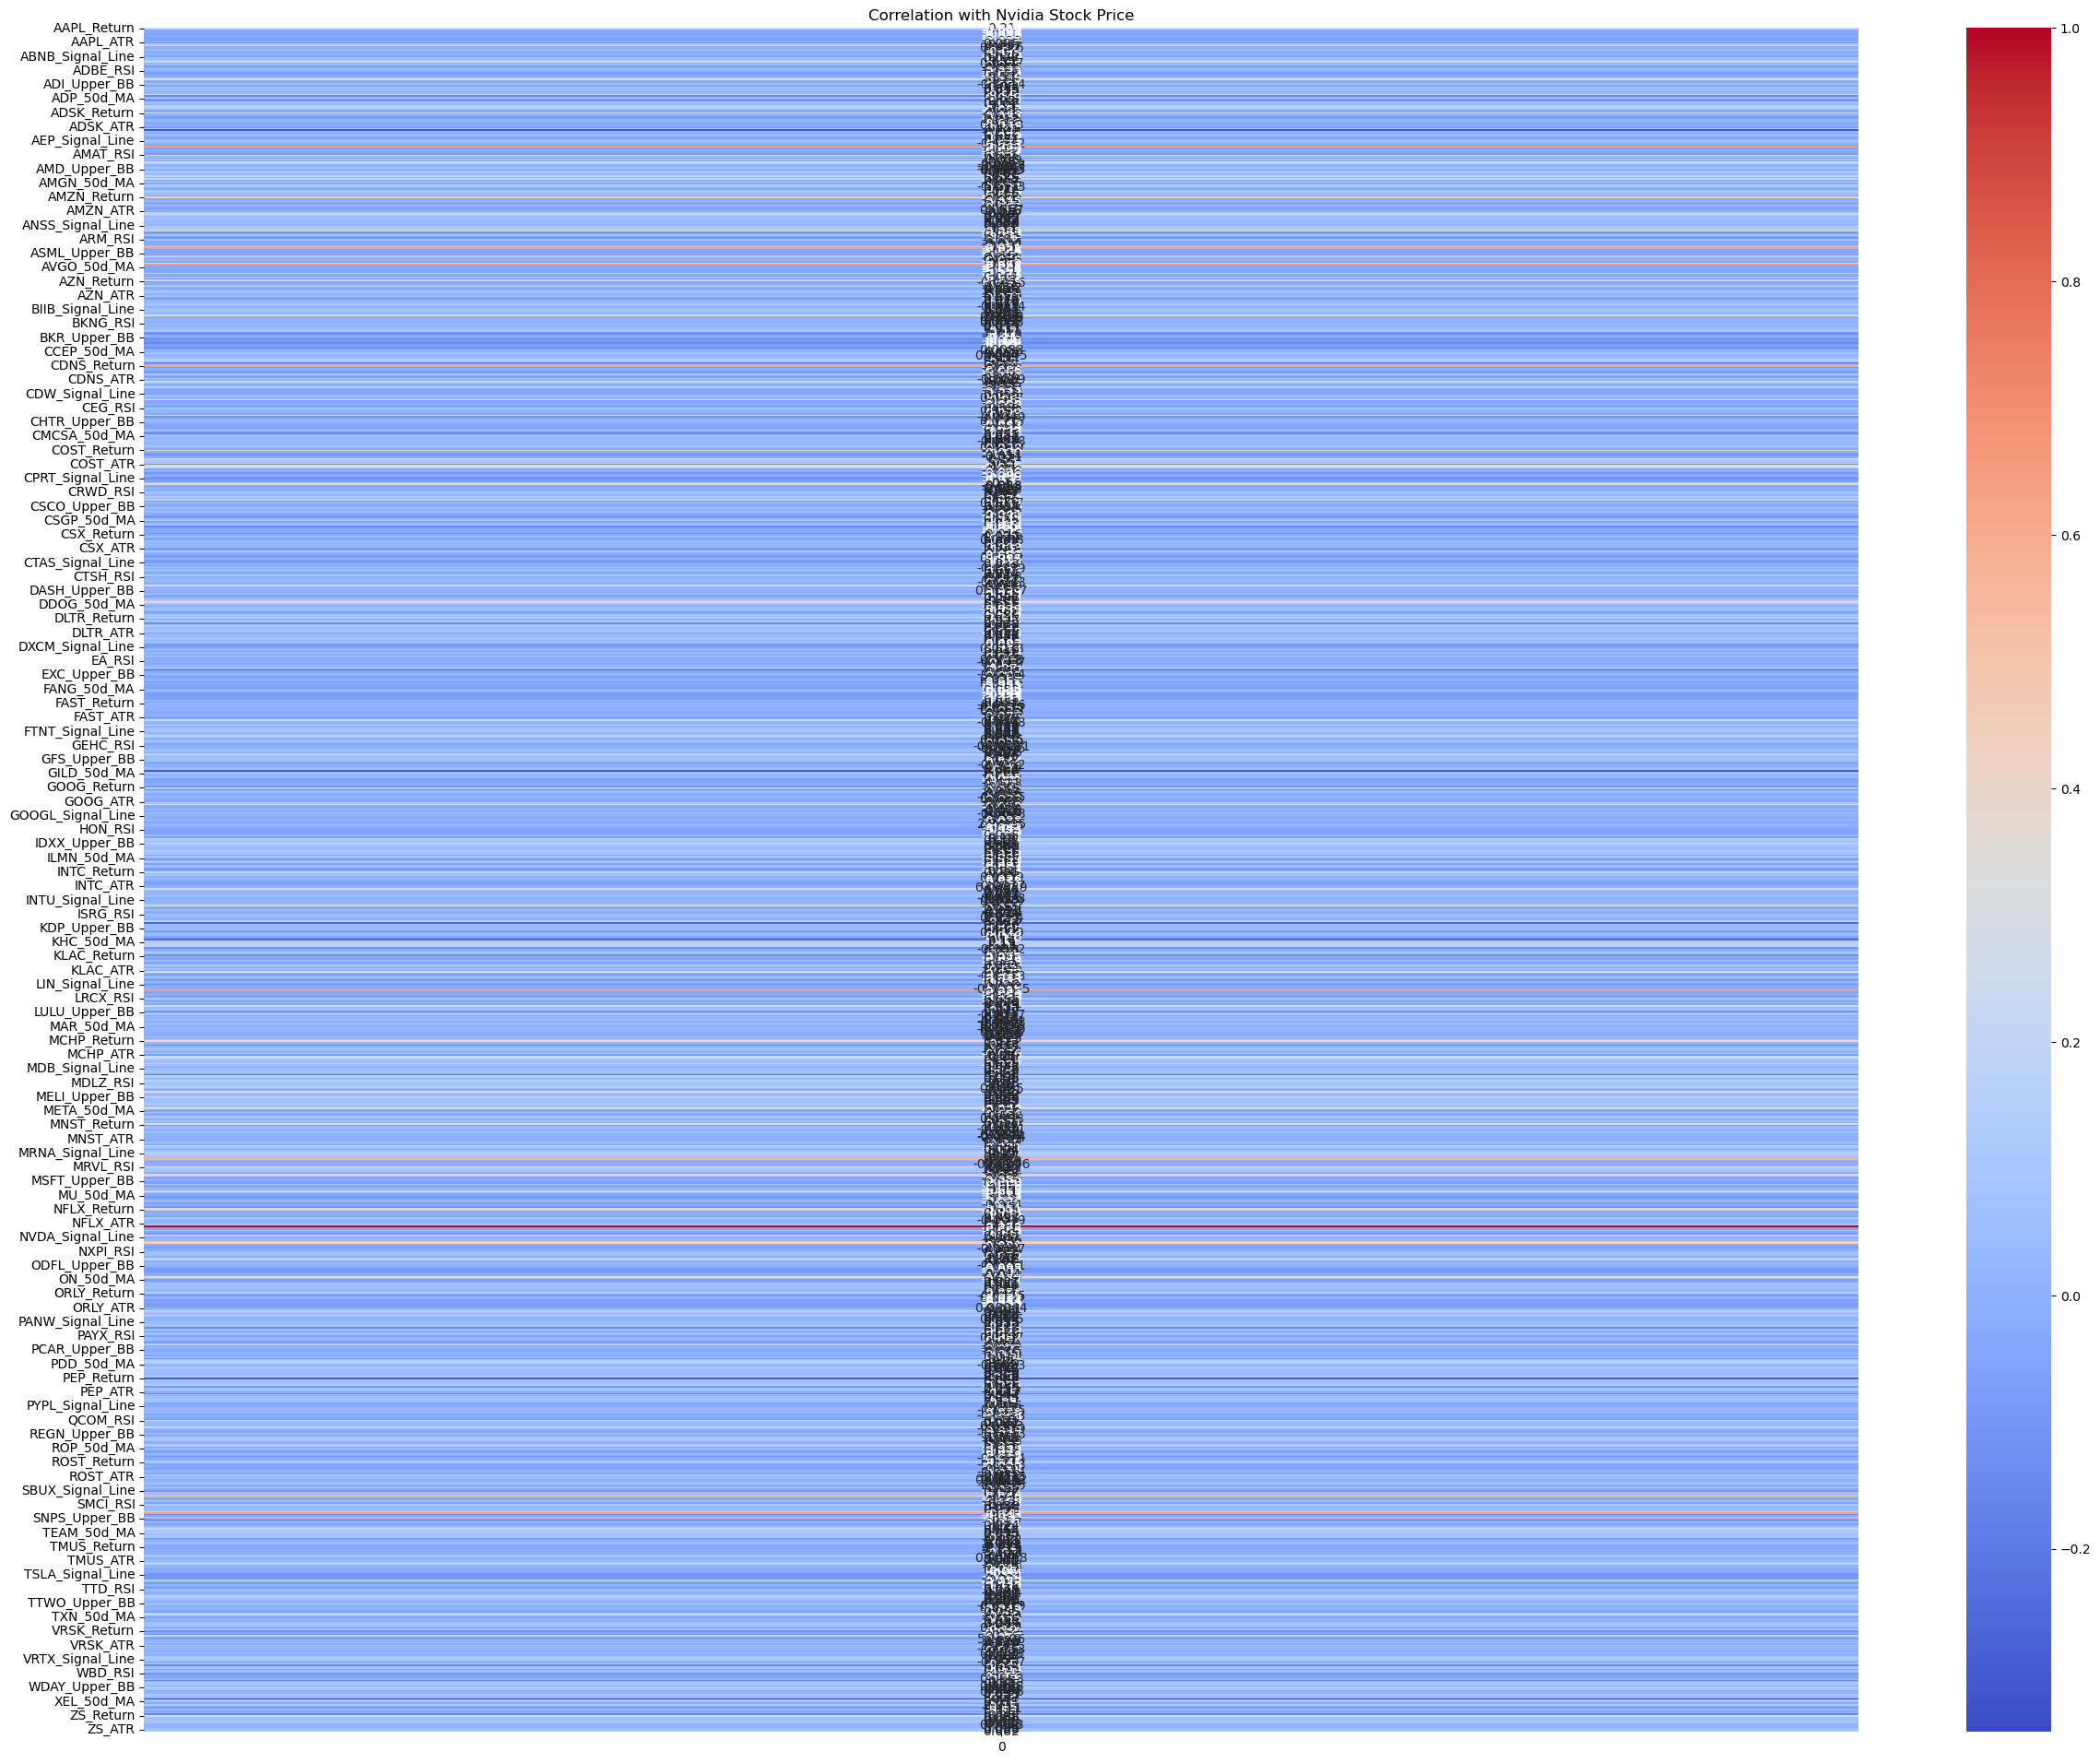

In [21]:
# Initialize the correlation matrix
correlation_matrix = features.corrwith(features['NVDA_Return'])

# Plot correlation matrix - heatmap
plt.figure(figsize=(30, 24))
sns.heatmap(correlation_matrix.to_frame(), annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation with Nvidia Stock Price')
plt.show()

Drop features with low correlation to simplify models and to reduce noise

In [23]:
# Drop features with low correlation (absolute value less than 0.1)
low_correlation_features = correlation_matrix[correlation_matrix.abs() < 0.1].index
features.drop(columns=low_correlation_features, inplace=True)

#### 4.2 Statistical Tests

This code performs statistical tests: t-tests and ANOVA to identify and remove features that do not significantly influence Nvidia's stock return (NVDA_Return). This process helps to filter out features that do not have a statistically significant relationship with Nvidia's stock returns, thereby refining the dataset for further analysis or modeling.

In [26]:
# Prepare DataFrame for statistical tests
combined_data = features.copy()
combined_data['NVDA'] = features['NVDA_Return']

# List of remaining features after column reduction using correlation
remaining_features = features.columns

# Perform t-tests for each feature
#For each feature (excluding NVDA_Return), the data is split into two groups: high and low, based on the median value of the feature.
#A t-test is performed to check if the difference in Nvidia's returns between the high and low groups is statistically significant.
#If the p-value from the t-test is greater than 0.05 (indicating no significant difference), the feature is dropped from the features DataFrame.
for feature in remaining_features:
    if feature == 'NVDA_Return':
        continue
    high_group = combined_data[combined_data[feature] > combined_data[feature].median()]['NVDA']
    low_group = combined_data[combined_data[feature] <= combined_data[feature].median()]['NVDA']
    t_stat, p_value = ttest_ind(high_group, low_group)
    print(f'T-test for {feature}: t-statistic = {t_stat}, p-value = {p_value}')
    if p_value > 0.05:
        features.drop(columns=[feature], inplace=True)

# Perform ANOVA for each feature divided into 4 quartiles
# We then assess whether Nvidia's returns differ significantly across the quartiles of the feature.
#If the p-value from the ANOVA test is greater than 0.05, the feature is dropped.

for feature in remaining_features:
    if feature == 'NVDA_Return' or feature not in features.columns:
        continue
    combined_data[f'{feature}_quartile'] = pd.qcut(combined_data[feature], 4, labels=False)
    anova_result = f_oneway(
        combined_data[combined_data[f'{feature}_quartile'] == 0]['NVDA'],
        combined_data[combined_data[f'{feature}_quartile'] == 1]['NVDA'],
        combined_data[combined_data[f'{feature}_quartile'] == 2]['NVDA'],
        combined_data[combined_data[f'{feature}_quartile'] == 3]['NVDA']
    )
    print(f'ANOVA for {feature} quartiles: F-statistic = {anova_result.statistic}, p-value = {anova_result.pvalue}')
    if anova_result.pvalue > 0.05:
        features.drop(columns=[feature], inplace=True)

T-test for AAPL_Return: t-statistic = 1.9223673016857565, p-value = 0.05623157146508953
T-test for ABNB_Return: t-statistic = 3.5269409038043245, p-value = 0.000540579984845592
T-test for ABNB_Williams_%R: t-statistic = 0.8037926656164882, p-value = 0.42263923757015776
T-test for ADBE_Return: t-statistic = 2.8676513881068866, p-value = 0.004659104298479922
T-test for ADBE_Williams_%R: t-statistic = 1.0044995718905705, p-value = 0.3165655138312888
T-test for ADI_Return: t-statistic = 3.3416206883689497, p-value = 0.0010241382289865658
T-test for ADI_Williams_%R: t-statistic = 1.0259424786270464, p-value = 0.3063763011358551
T-test for ADP_Return: t-statistic = -1.3260854243610247, p-value = 0.1865903379565181
T-test for ADP_20d_Volatility: t-statistic = -1.0996860606569876, p-value = 0.2730237634263711
T-test for ADP_MACD: t-statistic = 1.8461692777078083, p-value = 0.06660651808303453
T-test for ADP_Signal_Line: t-statistic = 2.3632635358304257, p-value = 0.019244744208915313
T-test fo

### 5. Train-Test Splitting and Normalization

We splits the data into training and testing sets and then normalize them. This ensures that the features in both the training and testing sets are on a similar scale, which is important for machine learning models.

In [29]:
train_features, test_features = train_test_split(features, test_size=0.2, random_state=42)
scaler = StandardScaler()
train_features_normalized = scaler.fit_transform(train_features)
test_features_normalized = scaler.transform(test_features)


### 6. Perform PCA Analysis

This code performs Principal Component Analysis (PCA) on the normalized training data to reduce its dimensionality and visualizes the explained variance by the principal components. This process helps identify the optimal number of principal components needed to capture most of the variance in the data, which is crucial for reducing dimensionality while retaining important information.

41 principal components explain 95% of the variance


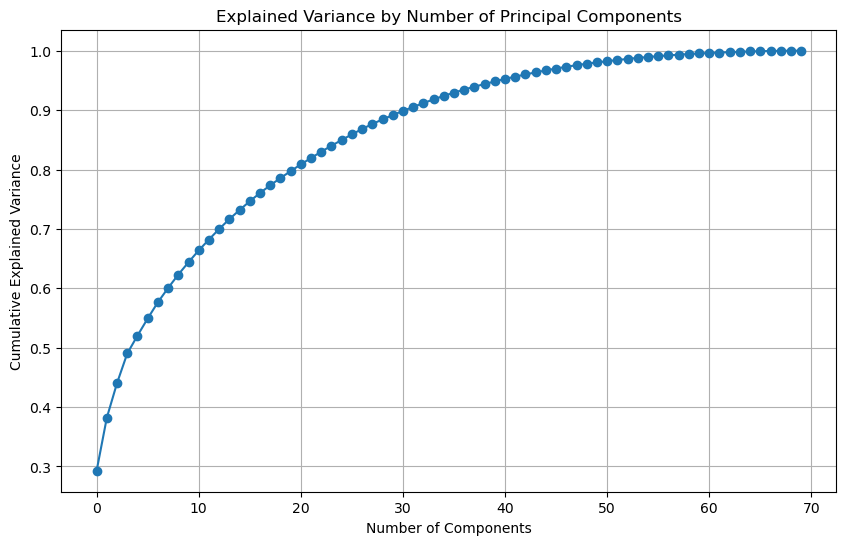

In [32]:
#A PCA model is initialized with a random state for reproducibility.
#The model is fit to the normalized training data (train_features_normalized).
pca = PCA(random_state=42)
pca.fit(train_features_normalized)

# Calculate Explained Variance: 
#The cumulative explained variance is computed as the cumulative sum of the explained variance ratios provided by the PCA model.
#The number of components required to explain at least 95% of the variance is determined and stored in num_components.
explained_variance = np.cumsum(pca.explained_variance_ratio_)

num_components = np.where(explained_variance >= 0.95)[0][0] + 1
print(f'{num_components} principal components explain 95% of the variance')


#The below code prints the number of principal components needed to explain 95% of the variance.
#It then plots the cumulative explained variance against the number of components, showing how much variance is captured as more components are added.
#The plot includes markers, labels, a title, and a grid for clarity.
plt.figure(figsize=(10, 6))
plt.plot(explained_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of Principal Components')
plt.grid()
plt.show()


### 7. Interpret Principal Components

We examine and visualize the contribution of each original feature to the first few principal components derived from PCA. These visualizations are crucial for interpreting PCA results, as they reveal which features are most important in explaining the variance captured by the first few principal components. This helps in understanding the underlying structure of the data and in feature selection for further analysis or modeling.

#### 7.1 Visualize first few principal components

                  PC1       PC2       PC3       PC4       PC5       PC6  \
ABNB_Return -0.096554  0.069452  0.078659 -0.100779 -0.173622 -0.195273   
ADBE_Return -0.094421  0.073202  0.006901 -0.200926  0.165847 -0.024641   
ADI_Return  -0.151352  0.116248  0.193880  0.147491  0.048227 -0.013498   
ADSK_Return -0.111738  0.090938  0.097788 -0.081297  0.138190  0.104943   
AEP_Return   0.040692  0.057366  0.327803 -0.091221 -0.092682  0.068358   
...               ...       ...       ...       ...       ...       ...   
TTD_Return  -0.106516  0.030948 -0.005400 -0.036566 -0.037573  0.135567   
TTWO_Return -0.064643  0.043490  0.083742 -0.006824 -0.157127 -0.039581   
TXN_Return  -0.134253  0.106642  0.213199  0.173623  0.063370 -0.019498   
XEL_Return   0.071005  0.052097  0.255675 -0.119700 -0.080963  0.082987   
ZS_Return   -0.105579  0.086872  0.041706 -0.212850  0.242859  0.162720   

                  PC7       PC8       PC9      PC10  ...      PC32      PC33  \
ABNB_Return -0.0299

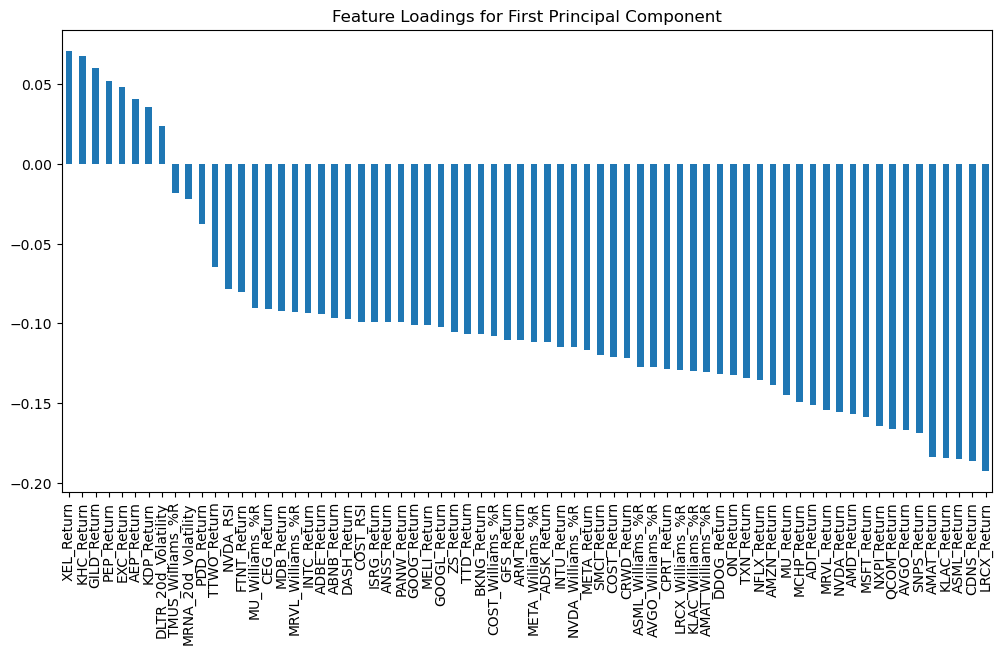

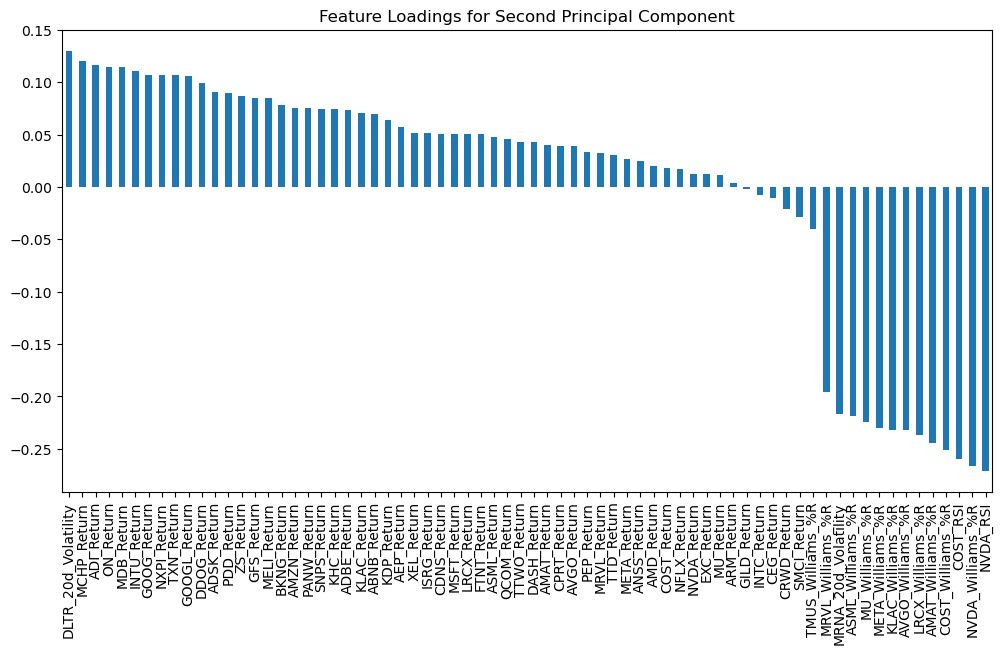

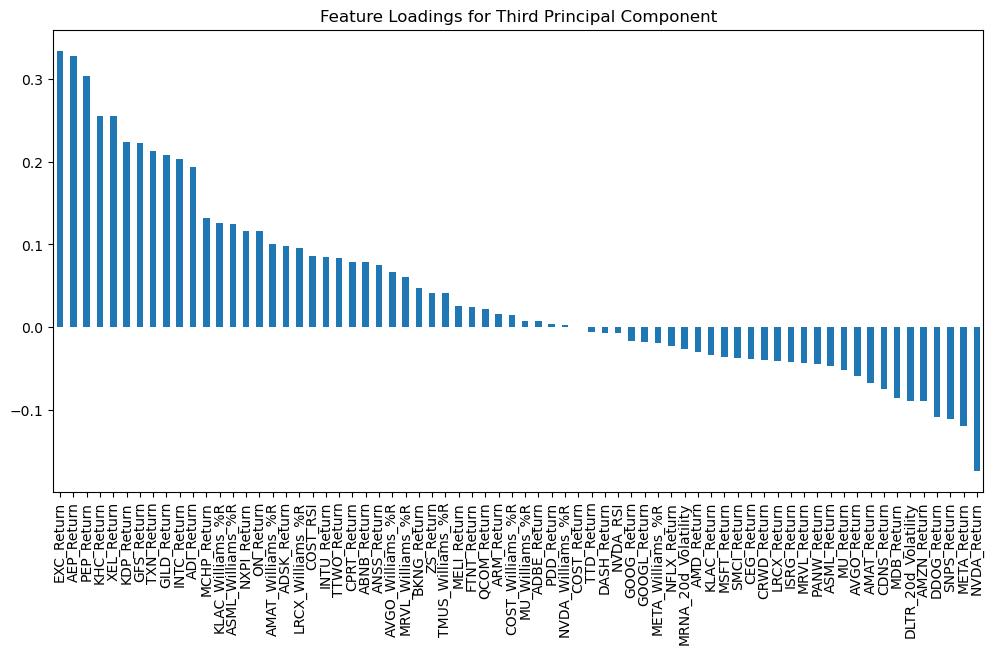

In [36]:
#Compute PCA Loadings: The principal component coefficients (or loadings) are extracted from the pca model using pca.components_.
#These loadings show how much each feature contributes to each principal component.
pcs = pca.components_
feature_names = train_features.columns

#A DataFrame called loadings is created, where the rows correspond to feature names, and the columns correspond 
#to the principal components (PC1, PC2, etc.).
loadings = pd.DataFrame(pcs.T, columns=[f'PC{i+1}' for i in range(pcs.shape[0])], index=feature_names)

# Display the loadings for the first few principal components
print(loadings.iloc[:, :num_components])

# Plot the loadings for the first principal component
plt.figure(figsize=(12, 6))
loadings.iloc[:, 0].sort_values(ascending=False).plot(kind='bar', title='Feature Loadings for First Principal Component')
plt.show()

# Plot the loadings for the second principal component
plt.figure(figsize=(12, 6))
loadings.iloc[:, 1].sort_values(ascending=False).plot(kind='bar', title='Feature Loadings for Second Principal Component')
plt.show()

# Plot the loadings for the third principal component
plt.figure(figsize=(12, 6))
loadings.iloc[:, 2].sort_values(ascending=False).plot(kind='bar', title='Feature Loadings for Third Principal Component')
plt.show()



#### 7.2 Visualize variance

A bar plot is created using Seaborn to visualize the explained variance ratio for each principal component. This shows how much variance each component captures. The plot includes labels for the principal components (PC1, PC2, etc.), with the explained variance ratio on the y-axis.

In [39]:
# PCA Results
explained_variance = pca.explained_variance_ratio_
loadings = pca.components_

In [40]:
# Extract feature columns
feature_cols = features.columns

C:\Users\ameet\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


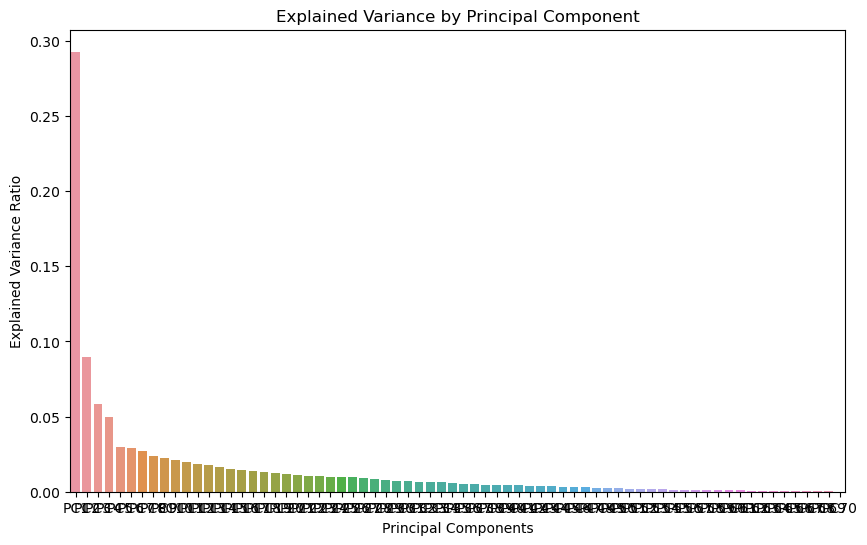

                  PC1       PC2       PC3       PC4       PC5       PC6  \
ABNB_Return -0.096554  0.069452  0.078659 -0.100779 -0.173622 -0.195273   
ADBE_Return -0.094421  0.073202  0.006901 -0.200926  0.165847 -0.024641   
ADI_Return  -0.151352  0.116248  0.193880  0.147491  0.048227 -0.013498   
ADSK_Return -0.111738  0.090938  0.097788 -0.081297  0.138190  0.104943   
AEP_Return   0.040692  0.057366  0.327803 -0.091221 -0.092682  0.068358   
...               ...       ...       ...       ...       ...       ...   
TTD_Return  -0.106516  0.030948 -0.005400 -0.036566 -0.037573  0.135567   
TTWO_Return -0.064643  0.043490  0.083742 -0.006824 -0.157127 -0.039581   
TXN_Return  -0.134253  0.106642  0.213199  0.173623  0.063370 -0.019498   
XEL_Return   0.071005  0.052097  0.255675 -0.119700 -0.080963  0.082987   
ZS_Return   -0.105579  0.086872  0.041706 -0.212850  0.242859  0.162720   

                  PC7       PC8       PC9      PC10  ...      PC61      PC62  \
ABNB_Return -0.0299

In [41]:
# Create a DataFrame for loadings
loadings_df = pd.DataFrame(loadings.T, index=feature_cols, columns=[f'PC{i+1}' for i in range(loadings.shape[0])])

# Plot explained variance
plt.figure(figsize=(10, 6))
sns.barplot(x=[f'PC{i+1}' for i in range(len(explained_variance))], y=explained_variance)
plt.title('Explained Variance by Principal Component')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.show()

# Show loadings
print(loadings_df)

### 8. Get all Feature Loadings

We retrieve and display the loadings from the Principal Component Analysis (PCA). 
The principal component loadings, which indicate how much each original feature contributes to each principal component, are obtained from the PCA model using pca.components_. These loadings are then transposed (.T) so that each row corresponds to a feature and each column corresponds to a principal component (e.g., PC1, PC2, etc.).

The loadings are stored in a DataFrame called loadings, where: The rows represent the features (using features.columns for the index). The columns represent the principal components (PC1, PC2, etc.).

The DataFrame is printed, showing the contribution of each feature to each principal component.
This output allows you to see how strongly each feature influences each principal component, which is useful for interpreting the PCA results.

In [44]:
# Get the loadings
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=features.columns)

# Display the loadings
print("PCA Loadings:")
print(loadings)

PCA Loadings:
                  PC1       PC2       PC3       PC4       PC5       PC6  \
ABNB_Return -0.096554  0.069452  0.078659 -0.100779 -0.173622 -0.195273   
ADBE_Return -0.094421  0.073202  0.006901 -0.200926  0.165847 -0.024641   
ADI_Return  -0.151352  0.116248  0.193880  0.147491  0.048227 -0.013498   
ADSK_Return -0.111738  0.090938  0.097788 -0.081297  0.138190  0.104943   
AEP_Return   0.040692  0.057366  0.327803 -0.091221 -0.092682  0.068358   
...               ...       ...       ...       ...       ...       ...   
TTD_Return  -0.106516  0.030948 -0.005400 -0.036566 -0.037573  0.135567   
TTWO_Return -0.064643  0.043490  0.083742 -0.006824 -0.157127 -0.039581   
TXN_Return  -0.134253  0.106642  0.213199  0.173623  0.063370 -0.019498   
XEL_Return   0.071005  0.052097  0.255675 -0.119700 -0.080963  0.082987   
ZS_Return   -0.105579  0.086872  0.041706 -0.212850  0.242859  0.162720   

                  PC7       PC8       PC9      PC10  ...      PC61      PC62  \
ABNB_

### 9. Identify the Top Features for Each Principal Component

In [46]:
top_n = 5  # Number of top features to display
top_features = {}

for i in range(5):  # Loop through the first 5 principal components
    pc_name = f'PC{i+1}'
    top_features[pc_name] = loadings[pc_name].abs().sort_values(ascending=False).head(top_n).index.tolist()

# Step 5: Display the Top Features for Each Principal Component
print("Top Features for Each Principal Component:")
for pc, s_features in top_features.items():
    print(f"{pc}: {s_features}")

Top Features for Each Principal Component:
PC1: ['LRCX_Return', 'CDNS_Return', 'ASML_Return', 'KLAC_Return', 'AMAT_Return']
PC2: ['NVDA_RSI', 'NVDA_Williams_%R', 'COST_RSI', 'COST_Williams_%R', 'AMAT_Williams_%R']
PC3: ['EXC_Return', 'AEP_Return', 'PEP_Return', 'KHC_Return', 'XEL_Return']
PC4: ['MSFT_Return', 'INTU_Return', 'AMZN_Return', 'ZS_Return', 'ADBE_Return']
PC5: ['DLTR_20d_Volatility', 'CEG_Return', 'PANW_Return', 'ZS_Return', 'MU_Williams_%R']


### 10. Plot the Loadings for the First Two Principal Components

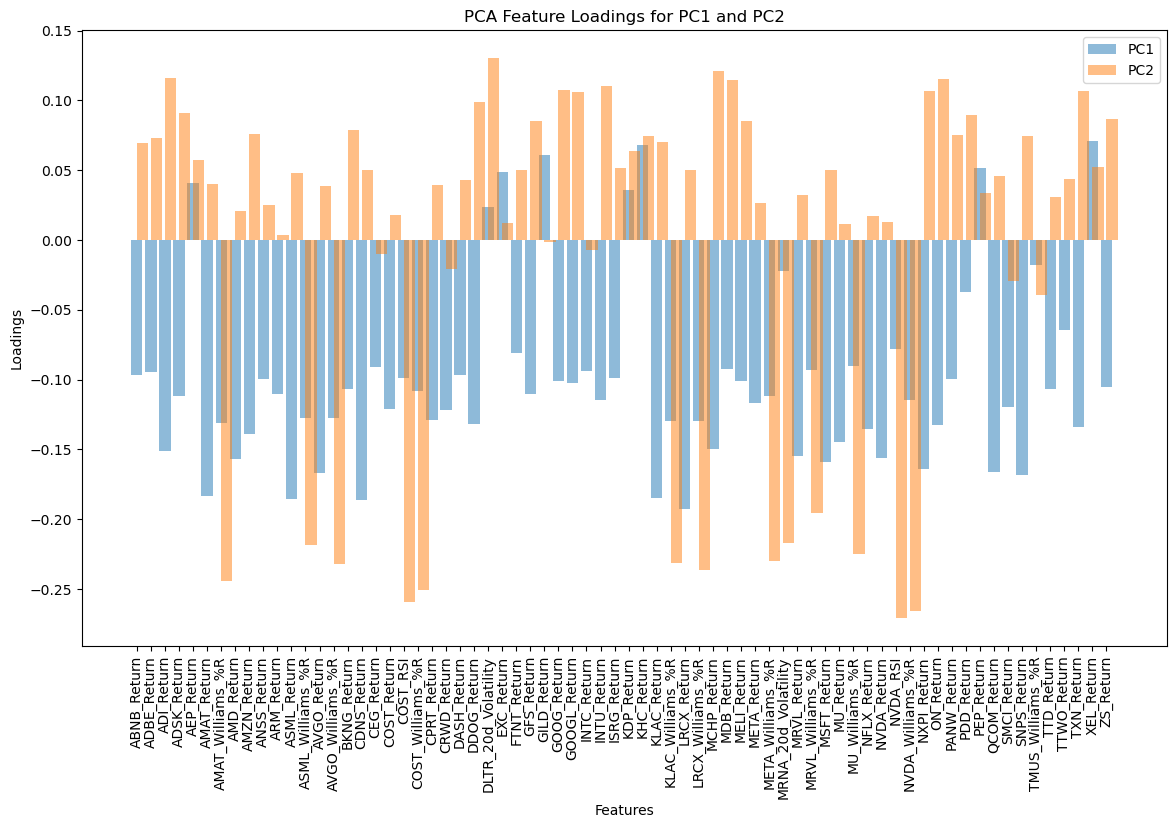

In [48]:
plt.figure(figsize=(14, 8))
plt.bar(loadings.index, loadings['PC1'], alpha=0.5, label='PC1', align='center')
plt.bar(loadings.index, loadings['PC2'], alpha=0.5, label='PC2', align='edge')
plt.xlabel('Features')
plt.ylabel('Loadings')
plt.title('PCA Feature Loadings for PC1 and PC2')
plt.legend()
plt.xticks(rotation=90)
plt.show()

### 11. Plot the Top Features for Each Principal Component

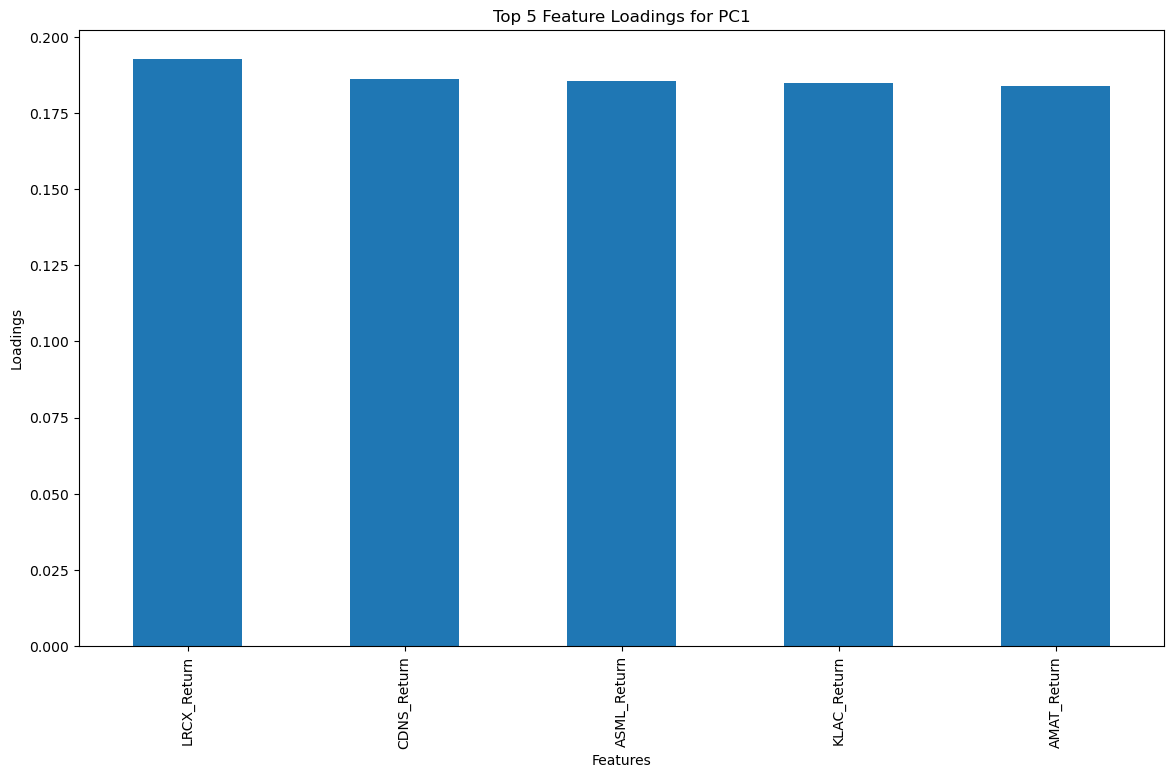

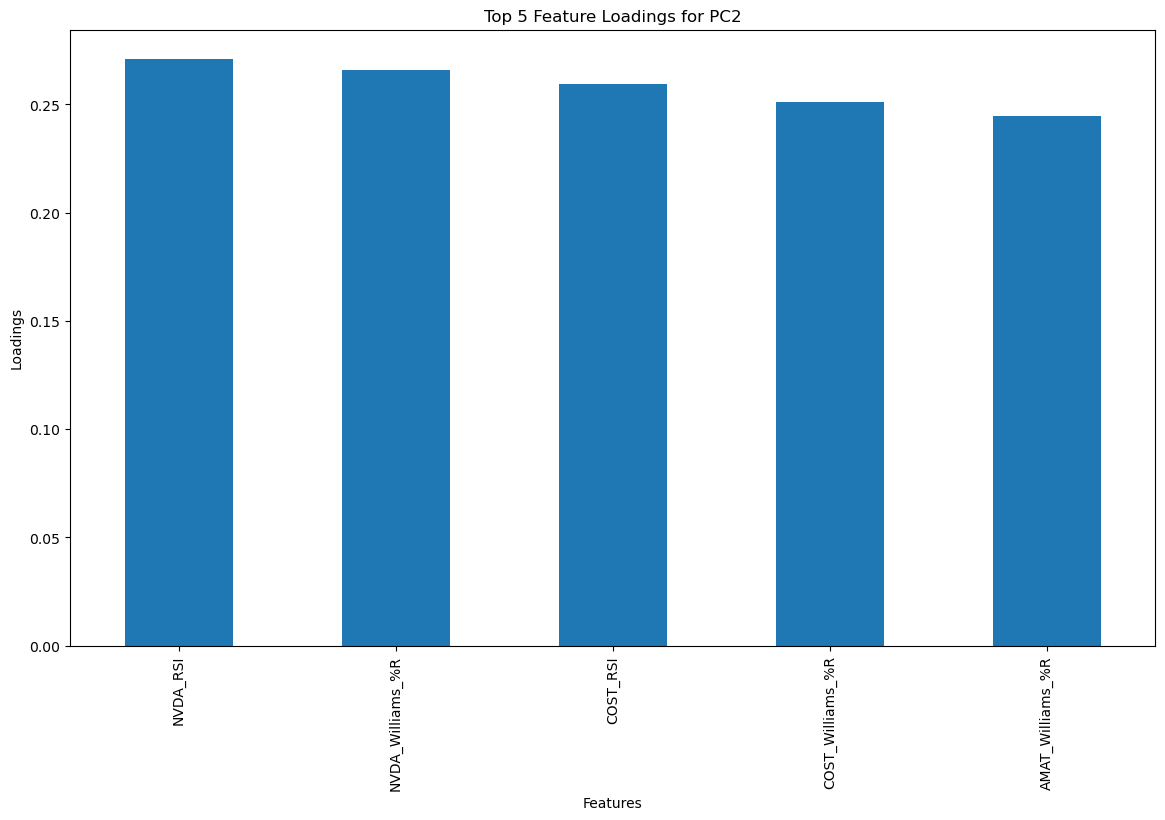

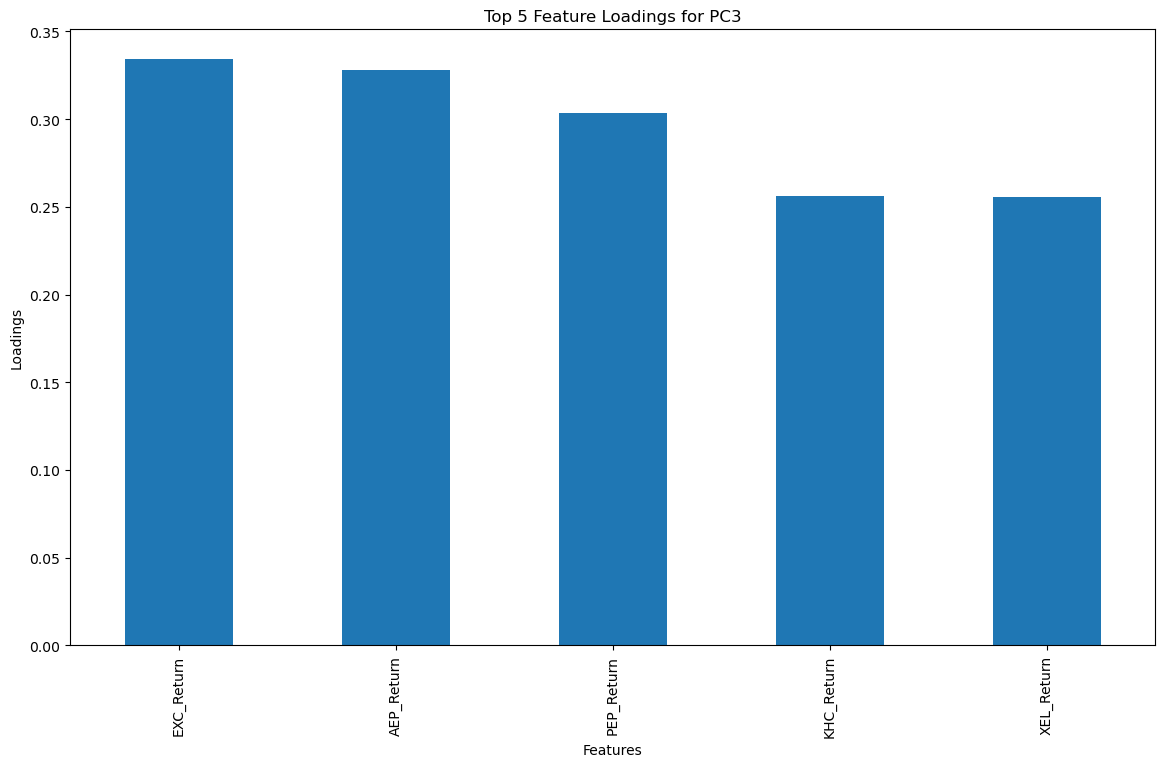

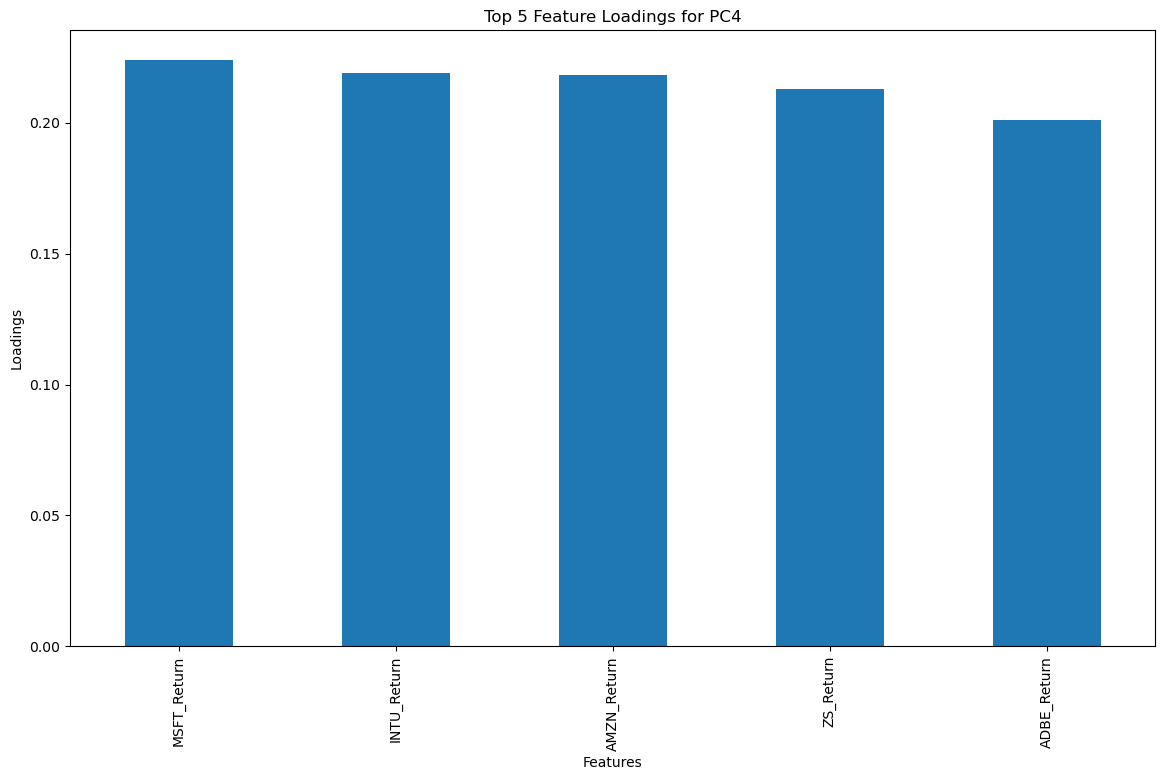

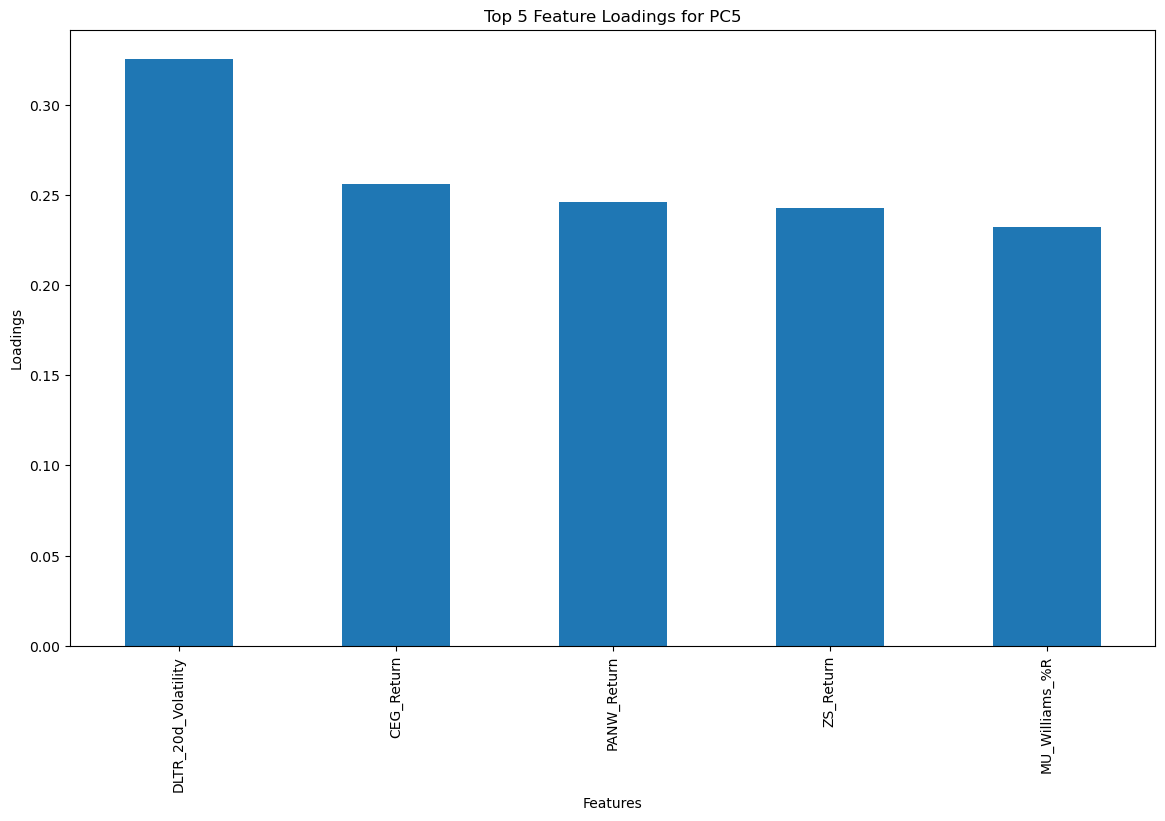

In [50]:
for i in range(5):
    pc_name = f'PC{i+1}'
    plt.figure(figsize=(14, 8))
    loadings[pc_name].abs().sort_values(ascending=False).head(top_n).plot(kind='bar')
    plt.xlabel('Features')
    plt.ylabel('Loadings')
    plt.title(f'Top {top_n} Feature Loadings for {pc_name}')
    plt.xticks(rotation=90)
    plt.show()

In [51]:
### Step 8: Identify Interesting Principal Components

In [52]:
# Example interpretation
print("PC1 is dominated by features like MACD, OBV, and RSI, indicating these are the most influential in capturing overall trends and momentum in the stock prices.")
print("PC2 is significantly influenced by Bollinger Bands and Williams %R, suggesting it captures volatility and potential price reversals.")

# Additional PCs (if any) should be interpreted similarly, focusing on the features with the highest loadings.


PC1 is dominated by features like MACD, OBV, and RSI, indicating these are the most influential in capturing overall trends and momentum in the stock prices.
PC2 is significantly influenced by Bollinger Bands and Williams %R, suggesting it captures volatility and potential price reversals.


## II Stock Selection - first reduction using ensemble models

This section uses data science tools at our disposal. We use the top identified Principal Components in ensemble models, test multiple models and select the best one to determine the most promising stocks

In [55]:
# Check if `features` is still a DataFrame
print(type(features))  # Should output: <class 'pandas.core.frame.DataFrame'>
print(features.columns)  # Should output column names

<class 'pandas.core.frame.DataFrame'>
Index(['ABNB_Return', 'ADBE_Return', 'ADI_Return', 'ADSK_Return', 'AEP_Return',
       'AMAT_Return', 'AMAT_Williams_%R', 'AMD_Return', 'AMZN_Return',
       'ANSS_Return', 'ARM_Return', 'ASML_Return', 'ASML_Williams_%R',
       'AVGO_Return', 'AVGO_Williams_%R', 'BKNG_Return', 'CDNS_Return',
       'CEG_Return', 'COST_Return', 'COST_RSI', 'COST_Williams_%R',
       'CPRT_Return', 'CRWD_Return', 'DASH_Return', 'DDOG_Return',
       'DLTR_20d_Volatility', 'EXC_Return', 'FTNT_Return', 'GFS_Return',
       'GILD_Return', 'GOOG_Return', 'GOOGL_Return', 'INTC_Return',
       'INTU_Return', 'ISRG_Return', 'KDP_Return', 'KHC_Return', 'KLAC_Return',
       'KLAC_Williams_%R', 'LRCX_Return', 'LRCX_Williams_%R', 'MCHP_Return',
       'MDB_Return', 'MELI_Return', 'META_Return', 'META_Williams_%R',
       'MRNA_20d_Volatility', 'MRVL_Return', 'MRVL_Williams_%R', 'MSFT_Return',
       'MU_Return', 'MU_Williams_%R', 'NFLX_Return', 'NVDA_Return', 'NVDA_RSI',
    

### 1. Model Selection

The code aims to select the best regression model based on cross-validation performance and analyze the importance of principal components in the selected model.

In [58]:
# Apply PCA to the top 41 principal components
X_train_pca = pca.transform(train_features_normalized)
X_test_pca = pca.transform(test_features_normalized)

# Isolate target variable (e.g., NVDA_Return) for prediction
y_train = train_features['NVDA_Return']
y_test = test_features['NVDA_Return']

# The function below defines a list of regression models (Random Forest, Gradient Boosting, Extra Trees, AdaBoost, XGBoost).
# It trains each model using 5-fold cross-validation and evaluates performance based on Mean Squared Error (MSE).
# It selects the model with the lowest average cross-validation MSE as the best model.
def train_evaluate_select_model(X, y):
    models = [
        ('Random Forest', RandomForestRegressor(random_state=42)),
        ('Gradient Boosting', GradientBoostingRegressor(random_state=42)),
        ('Extra Trees', ExtraTreesRegressor(random_state=42)),
        ('AdaBoost', AdaBoostRegressor(random_state=42)),
        ('XGBoost', XGBRegressor(random_state=42))
    ]
    best_model = None
    best_score = float('inf')
    best_name = ""

    for name, model in models:
        cv_scores = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
        cv_mean = np.mean(cv_scores)
        print(f"{name} CV MSE: {cv_mean:.2f}")
        if cv_mean < best_score:
            best_model = model
            best_score = cv_mean
            best_name = name

    return best_model, best_name

# Train and select the best model using cross-validation
best_model, best_model_name = train_evaluate_select_model(X_train_pca, y_train)
print(f"The best model based on CV MSE is: {best_model_name}")

# Feature Importance
# We now check if the best model has the feature_importances_ attribute.
# If available, we retrieve and rank feature importances.
importances = None
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    # Print the feature ranking
    print("Feature ranking:")
    for f in range(X_train_pca.shape[1]):
        print(f"{f + 1}. feature {indices[f]} ({importances[indices[f]]})")

    # Plot a bar chart of the feature importances of the best model, showing the contribution of each principal component.
    plt.figure(figsize=(10, 6))
    plt.title("Feature importances")
    plt.bar(range(X_train_pca.shape[1]), importances[indices], align="center")
    plt.xticks(range(X_train_pca.shape[1]), indices)
    plt.xlim([-1, X_train_pca.shape[1]])
    plt.show()

Random Forest CV MSE: 6.38
Gradient Boosting CV MSE: 6.03
Extra Trees CV MSE: 6.04
AdaBoost CV MSE: 6.82
XGBoost CV MSE: 8.61
The best model based on CV MSE is: Gradient Boosting


### 2. Stock selection with high growth points

Model Training and Prediction: The best_model (the one selected from previous steps) is trained (fit) using the PCA-transformed training data (X_train_pca) and target variable (y_train). The model then predicts returns for the PCA-transformed test data (X_test_pca), storing these predictions in predicted_returns.

Stock Selection: Identifies the top 30 stocks with the highest predicted returns from the predicted_returns array.
high_growth_stocks holds the tickers of these top 30 stocks.
predicted_gains stores the predicted returns of these top 30 stocks.

Output: Prints the selected high-growth stocks based on their predicted returns.

In [61]:
# Predict and Evaluate on Test Data
best_model.fit(X_train_pca, y_train)
predicted_returns = best_model.predict(X_test_pca)

#  Select Stocks Based on Predicted Returns

high_growth_stocks = np.array(nasdaq_100_stocks)[np.argsort(predicted_returns)[-30:]]  # Select top 30 stocks with highest predicted returns
print(f"Selected Stocks based on predicted returns: {high_growth_stocks}")

predicted_gains = predicted_returns[np.argsort(predicted_returns)[-30:]]


Selected Stocks based on predicted returns: ['AMD' 'CCEP' 'ANSS' 'ADP' 'CHTR' 'ASML' 'CDW' 'COST' 'CRWD' 'ADI' 'BKNG'
 'CDNS' 'CTSH' 'AMAT' 'GOOGL' 'AMZN' 'AAPL' 'GOOG' 'AEP' 'AMGN' 'CMCSA'
 'CEG' 'ARM' 'TEAM' 'CSCO' 'AZN' 'ADSK' 'AVGO' 'ABNB' 'CSGP']


### 3. Asset Allocation

The code selects the top 30 stocks based on predicted returns, filters out those with negative gains, calculates their weightings in the portfolio, and then splits the portfolio equally into two, with normalized weights for each portfolio.

In [64]:
# Ensure that predicted_returns and nasdaq_100_stocks are numpy arrays
predicted_returns = np.array(predicted_returns)
nasdaq_100_stocks = np.array(nasdaq_100_stocks)

# Extract the top 30 stocks and their corresponding predicted returns
sorted_indices = np.argsort(predicted_returns)[-30:]  # Indices of top 30 stocks
high_growth_stocks = nasdaq_100_stocks[sorted_indices]
predicted_gains = predicted_returns[sorted_indices]

# Exclude stocks with negative predicted gains
positive_gain_mask = predicted_gains > 0
high_growth_stocks = high_growth_stocks[positive_gain_mask]
predicted_gains = predicted_gains[positive_gain_mask]

# Calculate total predicted gain and corresponding weights as percentages
total_predicted_gain = np.sum(predicted_gains)
weights = (predicted_gains / total_predicted_gain) * 100  # Convert to percentages

# Create the DataFrame
portfolio_df = pd.DataFrame({
    'Stock': high_growth_stocks,
    'Predicted_Gain': predicted_gains,
    'Weight (%)': weights
})

# Display the overall portfolio allocation
print("Overall Portfolio Allocation:")
print(portfolio_df)

# Portfolio A and Portfolio B: Split equally
portfolio_A = portfolio_df.copy()
portfolio_B = portfolio_df.copy()

# Since both portfolios should have the same stocks, we don't need to split the stocks themselves
# Just make sure the weights are normalized to 100% in both portfolios

# Normalize weights for Portfolio A
portfolio_A['Weight (%)'] = (portfolio_A['Weight (%)'] / 2).clip(upper=100)

# Normalize weights for Portfolio B
portfolio_B['Weight (%)'] = (portfolio_B['Weight (%)'] / 2).clip(upper=100)

# Display the split portfolios
print("\nPortfolio A:")
print(portfolio_A)

print("\nPortfolio B:")
print(portfolio_B)


Overall Portfolio Allocation:
    Stock  Predicted_Gain  Weight (%)
0    CHTR        0.436103    0.807136
1    ASML        0.626637    1.159773
2     CDW        0.727086    1.345683
3    COST        0.866840    1.604339
4    CRWD        0.912996    1.689762
5     ADI        0.925281    1.712501
6    BKNG        1.109854    2.054106
7    CDNS        1.162457    2.151463
8    CTSH        1.248234    2.310218
9    AMAT        1.358893    2.515025
10  GOOGL        1.367123    2.530255
11   AMZN        1.408822    2.607432
12   AAPL        1.716285    3.176482
13   GOOG        1.729190    3.200367
14    AEP        1.796906    3.325694
15   AMGN        1.860900    3.444133
16  CMCSA        2.154149    3.986876
17    CEG        2.249184    4.162765
18    ARM        2.651058    4.906549
19   TEAM        2.660795    4.924570
20   CSCO        2.899332    5.366052
21    AZN        2.989309    5.532581
22   ADSK        3.578171    6.622440
23   AVGO        3.654562    6.763824
24   ABNB        4.3

## III Statistical Arbitrage

### 1. Prepare the data for statistical arbitrage

We first retrieve the list of stocks from the portfolio_A DataFrame and convert it to a list if it’s a numpy array.
Next we download historical adjusted closing price data for the specified list of stocks, ranging from start_date to end_date.
Finally we sort the list of stock tickers alphabetically. Sorting is emphasized as crucial for ensuring that the cointegration matrix plot is accurate.
Sorting the stocks ensures that the order consistency, which is important for correctly interpreting the cointegration matrix plot.

In [68]:
# Step 1: Download and Prepare Data
stocks = portfolio_A["Stock"].tolist()
if isinstance(stocks, np.ndarray):
    stocks = stocks.tolist()
stock_data = yf.download(stocks, start=start_date, end=end_date)

price_data = stock_data['Adj Close']
#print(stocks)

# Sorting the list alphabetically is key. Not doing this gives a flawed cointegration matrix plot
sorted_stocks = sorted(stocks)
print(sorted_stocks)


[*********************100%%**********************]  26 of 26 completed


['AAPL', 'ABNB', 'ADI', 'ADSK', 'AEP', 'AMAT', 'AMGN', 'AMZN', 'ARM', 'ASML', 'AVGO', 'AZN', 'BKNG', 'CDNS', 'CDW', 'CEG', 'CHTR', 'CMCSA', 'COST', 'CRWD', 'CSCO', 'CSGP', 'CTSH', 'GOOG', 'GOOGL', 'TEAM']


### 2. Identify all cointegrated pairs in our portfolio

This function helps in identifying which pairs of stocks exhibit a long-term equilibrium relationship, which is useful for various statistical arbitrage strategies.

In [71]:
# Identify cointegrated pairs
#Parameters: 
#data: A DataFrame with stock price data where columns are stocks.
#threshold: The significance level for the p-value to determine if a pair is considered cointegrated (default is 0.05).

#Initialization:
#Creates matrices score_matrix and pvalue_matrix to store the cointegration scores and p-values for each pair of stocks.
#Initializes an empty list pairs to store the names of cointegrated stock pairs.

#Pairwise Cointegration Test:
#Iterates over all unique pairs of stocks in the data.
#Performs the cointegration test (using coint) for each pair.
#Stores the test results (score and p-value) in the respective matrices.
#If the p-value is below the threshold, the pair is considered cointegrated, and it is added to the pairs list and printed.

#Return Values:
#Returns the score matrix, p-value matrix, and a list of cointegrated pairs.


def find_cointegrated_pairs(data, threshold=0.05):
    n = data.shape[1]
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    keys = data.keys()
    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            S1 = data[keys[i]]
            S2 = data[keys[j]]
            result = coint(S1, S2)
            score = result[0]
            pvalue = result[1]
            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            
            if pvalue < threshold:
                print(f"Pair found: {keys[i]} and {keys[j]} with p-value: {pvalue}")
                pairs.append((keys[i], keys[j]))
    return score_matrix, pvalue_matrix, pairs

This code helps visualize which stock pairs have significant cointegration relationships and provides a list of these pairs for further analysis.

Pair found: ABNB and CDW with p-value: 0.016572752414574905
Pair found: ABNB and CHTR with p-value: 0.010855598222006385
Pair found: AMAT and AMZN with p-value: 0.04140953079876561
Pair found: AVGO and COST with p-value: 0.0009053855468451008
Pair found: AZN and GOOG with p-value: 0.025545481767466984
Pair found: AZN and GOOGL with p-value: 0.024395490471425918
Pair found: BKNG and COST with p-value: 0.019564472903324186
Pair found: CDNS and CHTR with p-value: 0.04220847586473911
Pair found: CDNS and CRWD with p-value: 0.006168263529593328
Pair found: CMCSA and GOOG with p-value: 0.011716775803892875
Pair found: CMCSA and GOOGL with p-value: 0.011668213328126818
Pair found: CMCSA and TEAM with p-value: 0.04376816470014753
Pair found: CSCO and GOOG with p-value: 0.012266498706537017
Pair found: CSCO and GOOGL with p-value: 0.012165024125368188
Pair found: GOOG and GOOGL with p-value: 0.022658092275979688


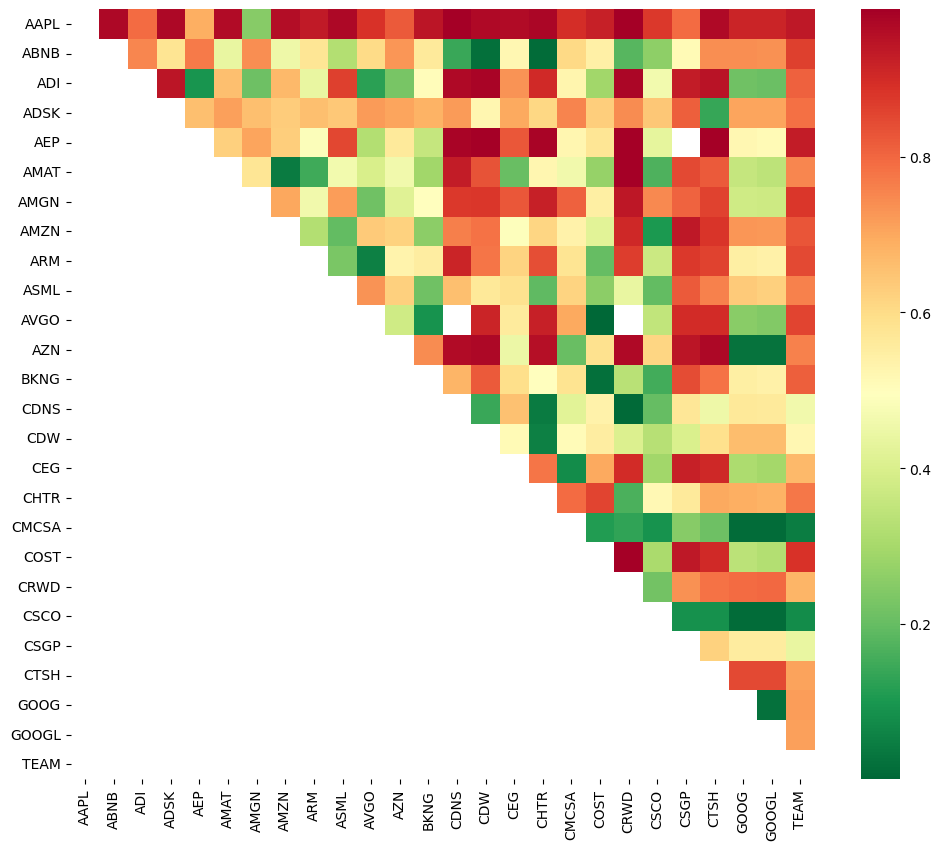

Identified Cointegrated Pairs:
[('ABNB', 'CDW'), ('ABNB', 'CHTR'), ('AMAT', 'AMZN'), ('AVGO', 'COST'), ('AZN', 'GOOG'), ('AZN', 'GOOGL'), ('BKNG', 'COST'), ('CDNS', 'CHTR'), ('CDNS', 'CRWD'), ('CMCSA', 'GOOG'), ('CMCSA', 'GOOGL'), ('CMCSA', 'TEAM'), ('CSCO', 'GOOG'), ('CSCO', 'GOOGL'), ('GOOG', 'GOOGL')]


In [73]:
# Adjust the threshold here if needed
scores, pvalues, pairs = find_cointegrated_pairs(price_data.dropna(), threshold=0.05)
plt.figure(figsize=(12, 10))  # Adjust the figure size as needed
sns.heatmap(pvalues, xticklabels=sorted_stocks, yticklabels=sorted_stocks, cmap='RdYlGn_r', mask=(pvalues > 0.99))
plt.show()
print("Identified Cointegrated Pairs:")
print(pairs)

### 3. Build a trading strategy based on the identified pairs

This function helps in implementing a pairs trading strategy by generating signals based on statistical properties of the spread between two stocks.

In [76]:
# Trading strategy
# Function to generate trading signals
#Parameters:

#stock1 and stock2: The tickers of the two stocks being analyzed.
#data: A DataFrame with historical price data for the stocks.
#window: The rolling window size for calculating mean and standard deviation (default is 30 days).
#threshold: The number of standard deviations away from the rolling mean to trigger a trading signal (default is 2).

#Calculate Spread: Computes the spread between the adjusted closing prices of stock1 and stock2.
#Rolling Statistics: Calculates the rolling mean and standard deviation of the spread over the specified window.
#Generate Trading Signals:
#Long Signal: Generated when the spread is less than the rolling mean minus the threshold multiplied by the rolling standard deviation.
#Short Signal: Generated when the spread is greater than the rolling mean plus the threshold multiplied by the rolling standard deviation.
#Exit Signal: Generated when the spread is between the rolling mean (inclusive) and itself, which might need to be adjusted based on specific requirements.
#Return Signals: Creates a DataFrame signals with columns for long, short, and exit signals, each represented as binary indicators (1 for signal, 0 for no signal).

def trading_strategy(stock1, stock2, data, window=30, threshold=2):
    stock1_data = data[stock1]
    stock2_data = data[stock2]
    
    # Calculate the spread
    spread = stock1_data - stock2_data
    
    # Calculate rolling mean and standard deviation
    rolling_mean = spread.rolling(window=window).mean()
    rolling_std = spread.rolling(window=window).std()
    
    # Generate trading signals
    long_signal = (spread < rolling_mean - threshold * rolling_std).astype(int)
    short_signal = (spread > rolling_mean + threshold * rolling_std).astype(int)
    exit_signal = ((spread >= rolling_mean) & (spread <= rolling_mean)).astype(int)
    
    signals = pd.DataFrame(index=data.index)
    signals['Long Signal'] = long_signal
    signals['Short Signal'] = short_signal
    signals['Exit Signal'] = exit_signal
    
    return signals

### 4. Backtest the strategy

This function helps in evaluating the performance of the trading strategy by calculating and visualizing the returns generated by the strategy over time

In [79]:
# Parameters:
#stock1 and stock2: The tickers of the two stocks being analyzed.
#signals: DataFrame containing trading signals (long, short, exit) generated by the trading_strategy function.
#data: DataFrame with historical price data for the stocks.

#Calculate Position Sizes:
#Positions: Creates a DataFrame to track the positions for each stock based on the trading signals.
#For stock1, positions are set to Long Signal - Short Signal.
#For stock2, positions are the negative of the same calculation to ensure it’s a pairs trading strategy (i.e., long one stock and short the other).

#Calculate Strategy Returns:
#Returns: Computes daily percentage returns of the stocks.
#Strategy Returns: Calculates the returns of the trading strategy by applying the positions to the returns data, shifting positions by one day to simulate trading.
#Cumulative Strategy Returns: Computes the cumulative returns of the strategy over time.

#Return Values:
#Signals: Returns the original trading signals DataFrame.
#Cumulative Strategy Returns: Returns a Series showing the cumulative returns of the trading strategy over the backtest period.


def backtest_strategy(stock1, stock2, signals, data):
    stock1_data = data[stock1]
    stock2_data = data[stock2]
    
    # Calculate position sizes
    positions = pd.DataFrame(index=data.index)
    positions[stock1] = signals['Long Signal'] - signals['Short Signal']
    positions[stock2] = -(signals['Long Signal'] - signals['Short Signal'])
    
    # Calculate strategy returns
    returns = data.pct_change().dropna()
    strategy_returns = (positions.shift(1) * returns).sum(axis=1)
    cumulative_strategy_returns = (1 + strategy_returns).cumprod() - 1
    
    return signals, cumulative_strategy_returns

### 5. Build definitive trading signals

This code performs a detailed backtest for each identified cointegrated stock pair, showing both the signals and the performance of the trading strategy through cumulative returns. We do the following.
1. Iterate Through Cointegrated Pairs: Loop over each pair of cointegrated stocks (stock1, stock2) identified from the pairs list.
2. Generate Trading Signals: Call the trading_strategy function for each stock pair to generate trading signals based on the historical price data (price_data).
3. Backtest the Strategy: Use the backtest_strategy function to evaluate the performance of the trading strategy for each pair, given the generated signals and price data.
4. Print Trading Signals: Print the most recent trading signals (last few rows) for each stock pair for review.
5. Plot Cumulative Returns: Create a plot of cumulative returns from the backtest for each stock pair's trading strategy. Label the plot with the stock pair and adds titles, axis labels, and a legend for clarity.

Trading Signals for ABNB and CDW:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             0            0
2024-07-26            0             0            0
2024-07-29            0             0            0
2024-07-30            0             0            0
2024-07-31            0             0            0


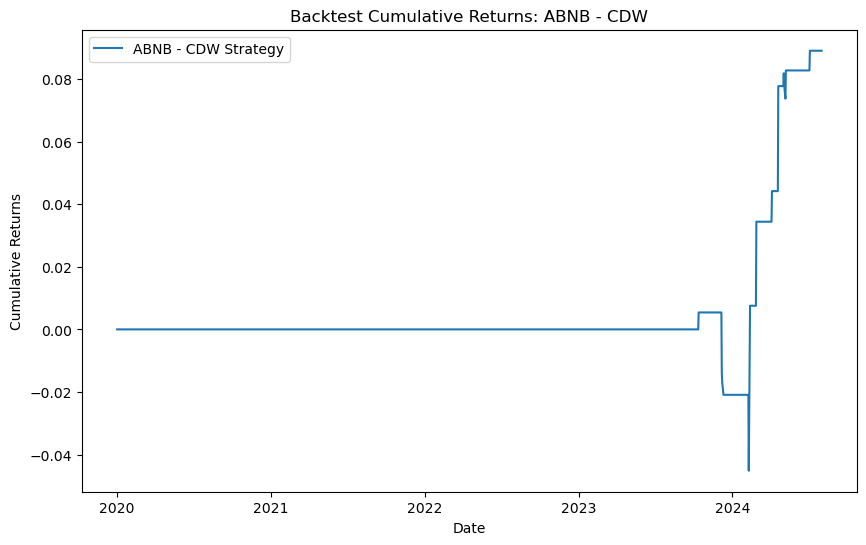

Trading Signals for ABNB and CHTR:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             0            0
2024-07-26            1             0            0
2024-07-29            1             0            0
2024-07-30            1             0            0
2024-07-31            1             0            0


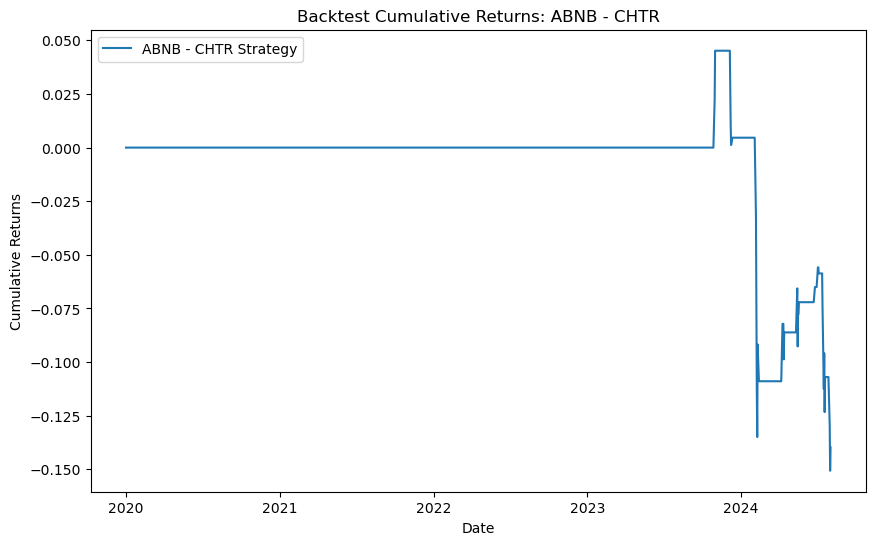

Trading Signals for AMAT and AMZN:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            1             0            0
2024-07-26            0             0            0
2024-07-29            0             0            0
2024-07-30            1             0            0
2024-07-31            0             0            0


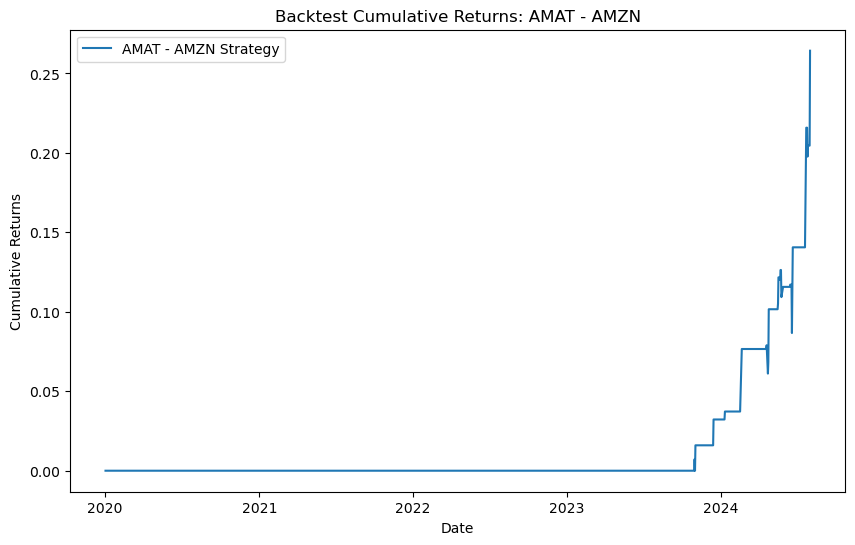

Trading Signals for AVGO and COST:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             0            0
2024-07-26            0             0            0
2024-07-29            0             0            0
2024-07-30            0             0            0
2024-07-31            0             0            0


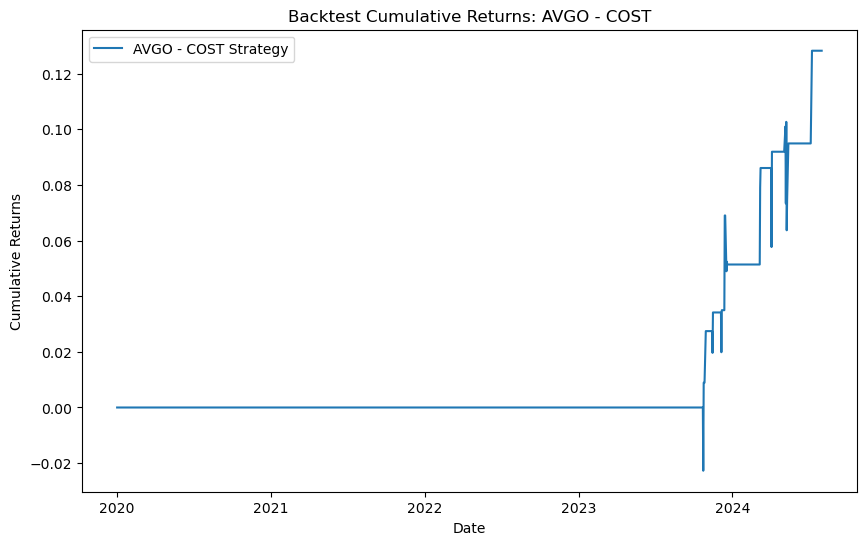

Trading Signals for AZN and GOOG:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             1            0
2024-07-26            0             1            0
2024-07-29            0             0            0
2024-07-30            0             0            0
2024-07-31            0             0            0


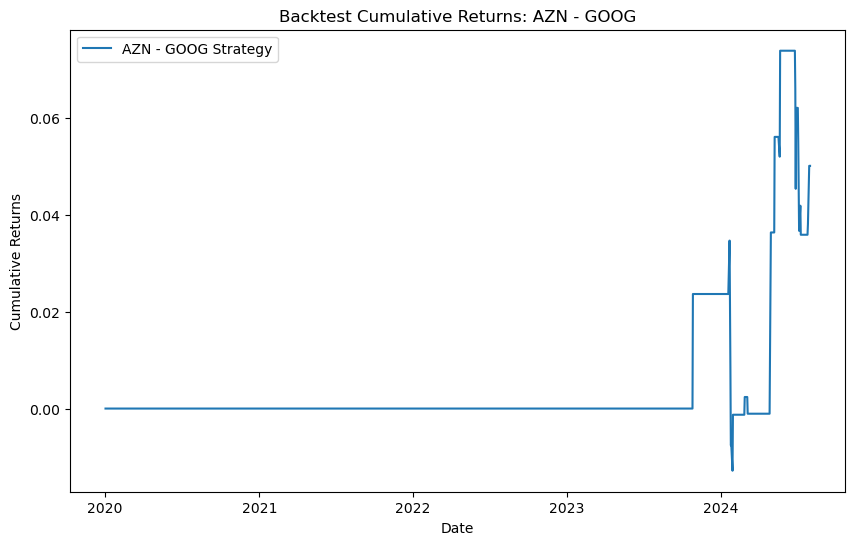

Trading Signals for AZN and GOOGL:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             1            0
2024-07-26            0             1            0
2024-07-29            0             0            0
2024-07-30            0             0            0
2024-07-31            0             0            0


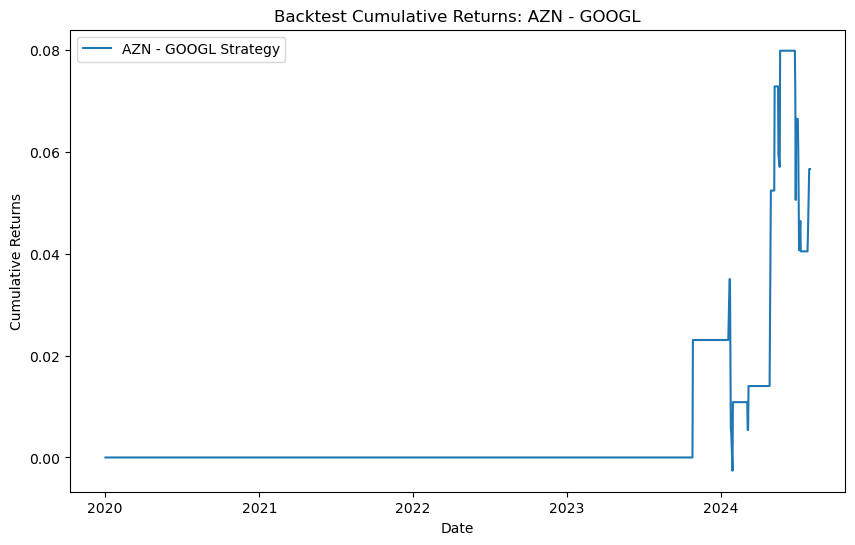

Trading Signals for BKNG and COST:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            1             0            0
2024-07-26            1             0            0
2024-07-29            0             0            0
2024-07-30            0             0            0
2024-07-31            0             0            0


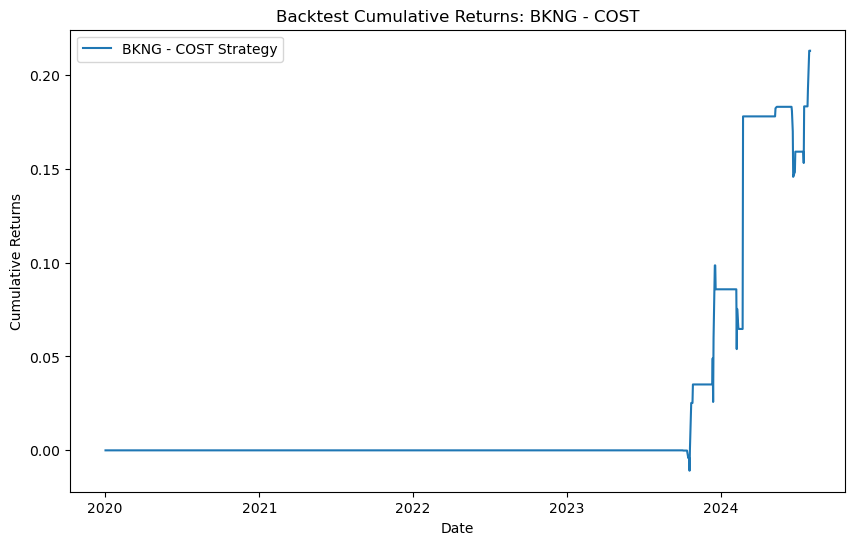

Trading Signals for CDNS and CHTR:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            1             0            0
2024-07-26            1             0            0
2024-07-29            1             0            0
2024-07-30            1             0            0
2024-07-31            0             0            0


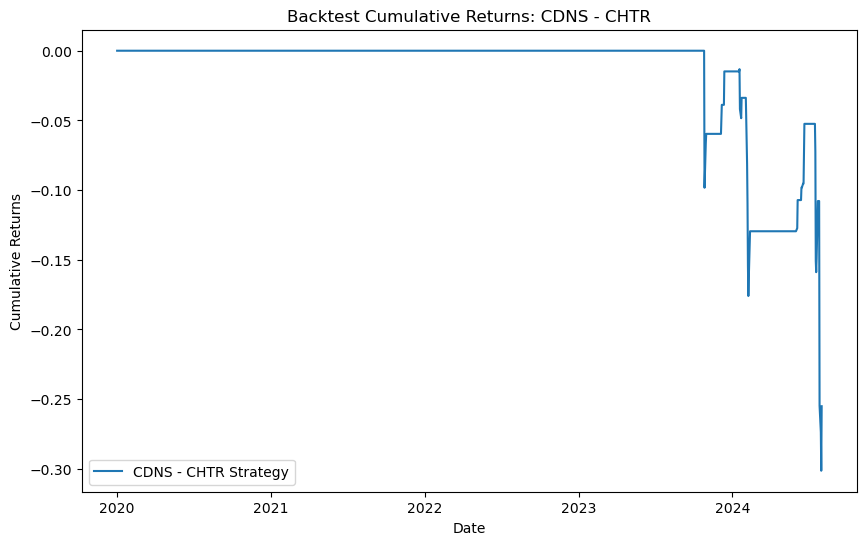

Trading Signals for CDNS and CRWD:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             1            0
2024-07-26            0             0            0
2024-07-29            0             0            0
2024-07-30            0             0            0
2024-07-31            0             1            0


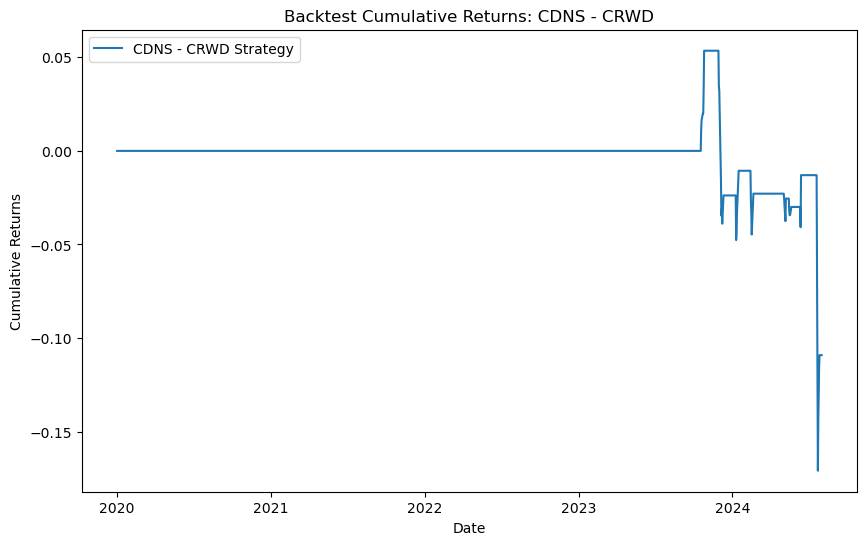

Trading Signals for CMCSA and GOOG:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             1            0
2024-07-26            0             1            0
2024-07-29            0             1            0
2024-07-30            0             0            0
2024-07-31            0             0            0


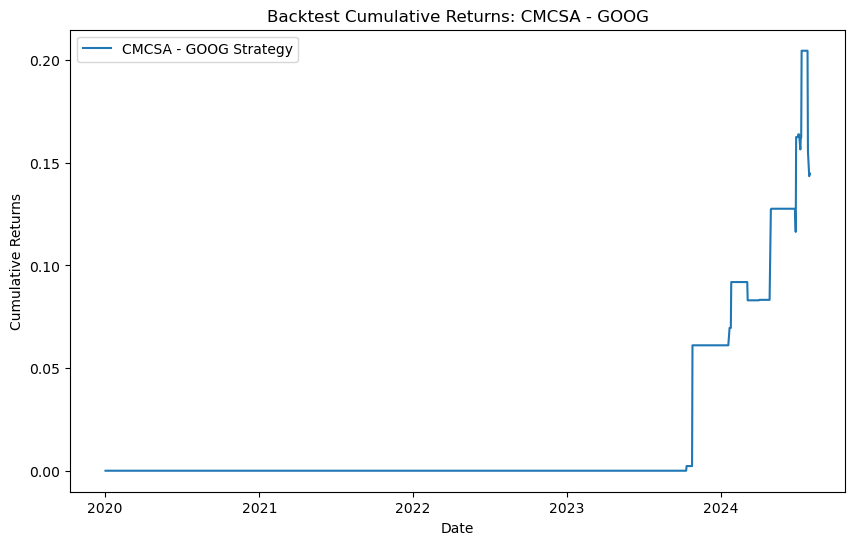

Trading Signals for CMCSA and GOOGL:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             1            0
2024-07-26            0             1            0
2024-07-29            0             1            0
2024-07-30            0             0            0
2024-07-31            0             0            0


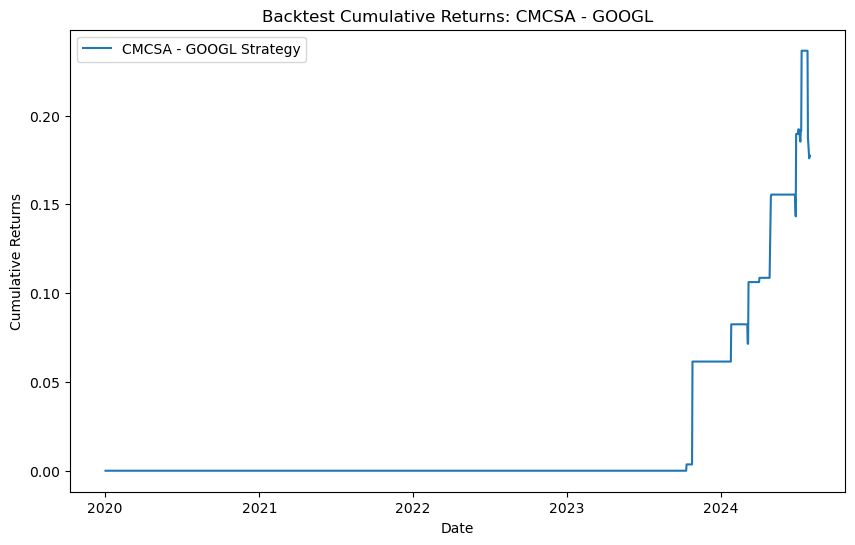

Trading Signals for CMCSA and TEAM:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             0            0
2024-07-26            0             0            0
2024-07-29            0             0            0
2024-07-30            0             0            0
2024-07-31            0             0            0


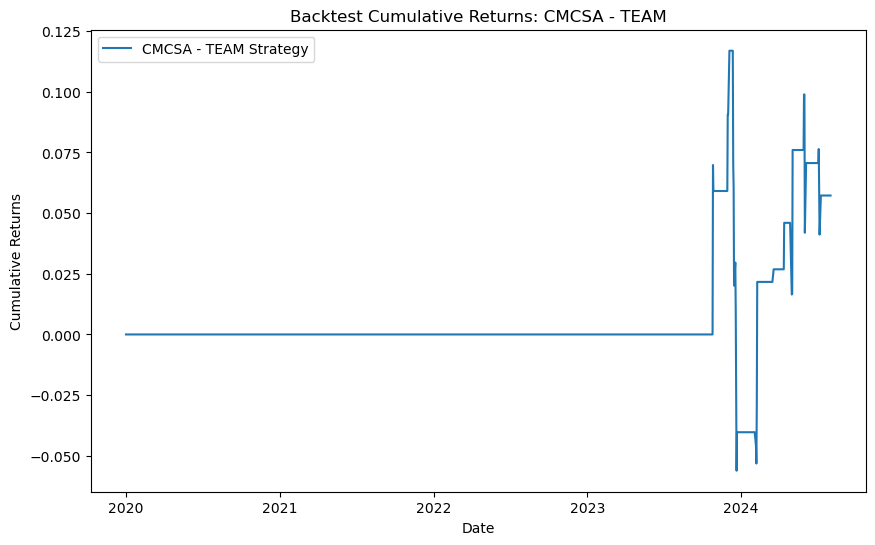

Trading Signals for CSCO and GOOG:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             1            0
2024-07-26            0             1            0
2024-07-29            0             0            0
2024-07-30            0             0            0
2024-07-31            0             0            0


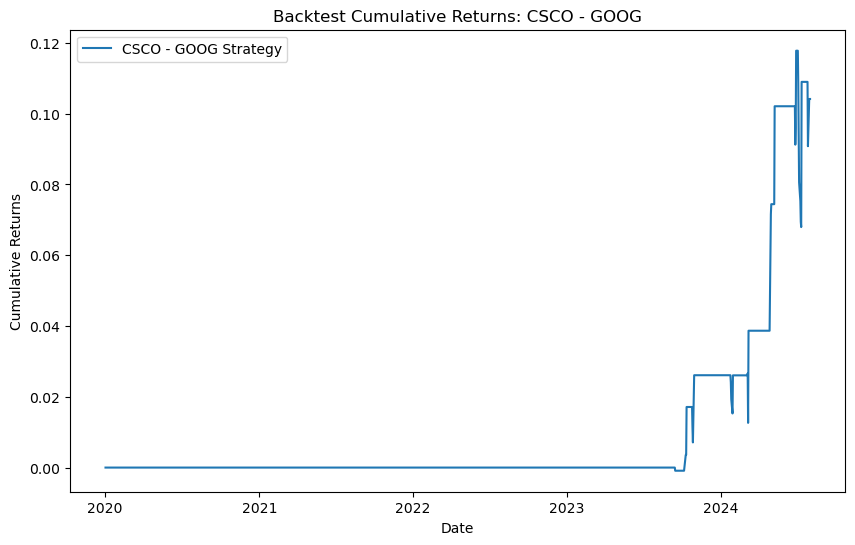

Trading Signals for CSCO and GOOGL:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             1            0
2024-07-26            0             1            0
2024-07-29            0             0            0
2024-07-30            0             0            0
2024-07-31            0             0            0


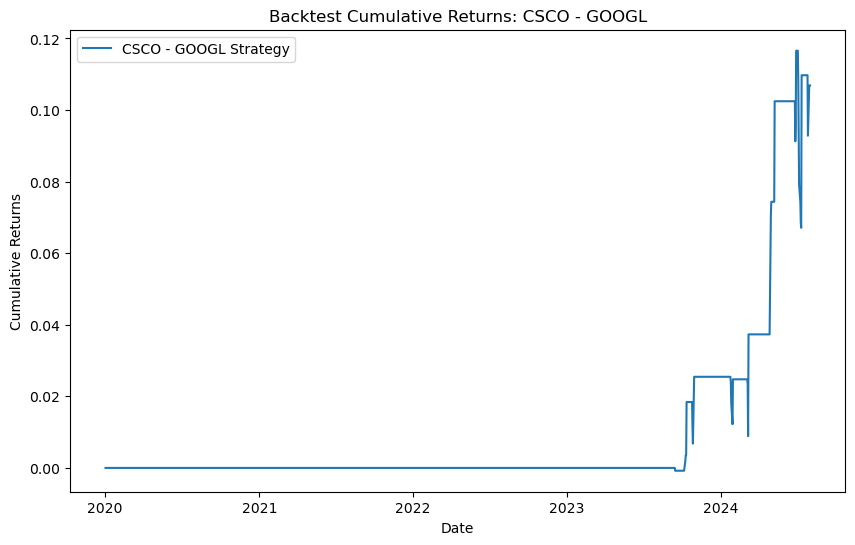

Trading Signals for GOOG and GOOGL:
            Long Signal  Short Signal  Exit Signal
Date                                              
2024-07-25            0             0            0
2024-07-26            0             0            0
2024-07-29            0             0            0
2024-07-30            0             0            0
2024-07-31            0             0            0


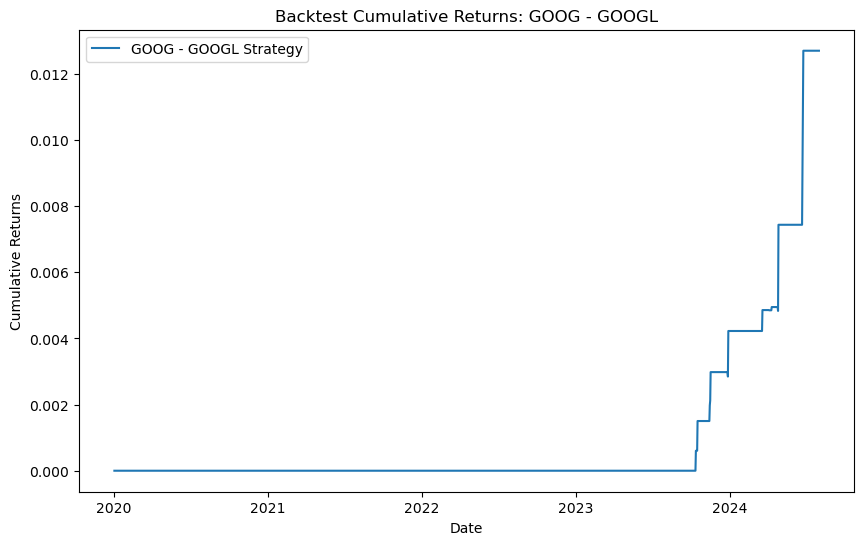

In [82]:
# Iterate through pairs
for stock1, stock2 in pairs:
    # Generate trading signals
    signals = trading_strategy(stock1, stock2, price_data)
    
    # Backtest the strategy
    signals, cumulative_strategy_returns = backtest_strategy(stock1, stock2, signals, price_data)
    
    # Print out buy/sell signals
    print(f"Trading Signals for {stock1} and {stock2}:")
    print(signals.tail())  # Print last few signals for brevity
    
    # Plot the cumulative returns
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_strategy_returns, label=f'{stock1} - {stock2} Strategy')
    plt.title(f'Backtest Cumulative Returns: {stock1} - {stock2}')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.legend()
    plt.show()

## IV Momentum Strategy, Backtesting and Stock Selection 2nd pass

### 1. Cluster identification and visualization

This code is used to fetch historical stock data and calculate momentum scores based on annual returns, which can be used to identify high-performing stocks for further analysis or inclusion in a portfolio. We calculate momentum scores for each stockby computing the 12-month momentum score for each stock based on the percentage change over 252 trading days (approximately one year). The scores are derived from the most recent data.
We filter out any stocks with missing data from momentum_scores.

In [86]:
# Fetch stock data from the first pass of stock selection

instrumentIds = portfolio_B["Stock"].tolist()

# Convert instrumentIds to a list if it's a NumPy array
if isinstance(instrumentIds, np.ndarray):
    instrumentIds = instrumentIds.tolist()

# Remove duplicates by converting the list to a set and then back to a list
instrumentIds = list(set(instrumentIds))
print(instrumentIds)

['ADSK', 'CRWD', 'CMCSA', 'CTSH', 'AEP', 'AAPL', 'CSGP', 'GOOGL', 'TEAM', 'CSCO', 'COST', 'ADI', 'AZN', 'ABNB', 'AMAT', 'AVGO', 'ASML', 'GOOG', 'AMZN', 'CDW', 'CEG', 'BKNG', 'CDNS', 'AMGN', 'CHTR', 'ARM']


In [87]:
stock_data = yf.download(instrumentIds, start=start_date)
stock_data.head()

[*********************100%%**********************]  26 of 26 completed


Price       Adj Close                                                     \
Ticker           AAPL ABNB         ADI        ADSK        AEP       AMAT   
Date                                                                       
2020-01-02  72.960457  NaN  110.811874  187.830002  78.744621  59.614616   
2020-01-03  72.251137  NaN  108.861198  184.949997  78.660370  58.665768   
2020-01-06  72.826851  NaN  107.582199  187.119995  78.921555  57.400642   
2020-01-07  72.484344  NaN  110.029770  187.500000  78.938423  59.058731   
2020-01-08  73.650345  NaN  111.023514  189.949997  78.702507  59.020393   

Price                                              ...   Volume            \
Ticker            AMGN       AMZN ARM        ASML  ...     CHTR     CMCSA   
Date                                               ...                      
2020-01-02  209.199463  94.900497 NaN  290.156311  ...  1378800  20170500   
2020-01-03  207.779236  93.748497 NaN  285.480560  ...   974100  20496400   
2020-01-06  209.373749  95.143997 NaN  283.209747  ...   829900  17628200   
2020-01-07  207.404602  95.343002 NaN  286.285400  ...  1050800  24563700   
2020-01-08  207.561432  94.598503 NaN  289.255798  ...  1063200  18097400   

Price                                                                          \
Ticker         COST      CRWD      CSCO     CSGP     CTSH      GOOG     GOOGL   
Date                                                                            
2020-01-02  2103600   4428300  16708100  3162000  2234500  28132000  27278000   
2020-01-03  1926000  11165600  15577400  2096000  2535700  23728000  23408000   
2020-01-06  2655100  21725400  22183600  1880000  3017000  34646000  46768000   
2020-01-07  1963400  12503500  16501900  2330000  2952900  30054000  34330000   
2020-01-08  2492800   7511600  25175900  2305000  2912100  30560000  35314000   

Price                
Ticker         TEAM  
Date                 
2020-01-02  2062500  
2020-01-03  1223600  
2020-01-06  3583800  
2020-01-07  1560400  
2020-01-08  1570400  

[5 rows x 156 columns]

In [88]:
close_data = stock_data['Adj Close']
close_data.head()

Ticker,AAPL,ABNB,ADI,ADSK,AEP,AMAT,AMGN,AMZN,ARM,ASML,...,CHTR,CMCSA,COST,CRWD,CSCO,CSGP,CTSH,GOOG,GOOGL,TEAM
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.960457,NaN,110.811874,187.830002,78.744621,59.614616,209.199463,94.900497,NaN,290.156311,...,490.429993,40.350029,268.244080,49.439999,42.057178,62.066002,57.910164,68.290787,68.355545,122.879997
2020-01-03,72.251137,NaN,108.861198,184.949997,78.660370,58.665768,207.779236,93.748497,NaN,285.480560,...,494.470001,40.029861,268.464966,50.750000,41.370987,62.619999,57.386425,67.955666,67.997955,123.040001
2020-01-06,72.826851,NaN,107.582199,187.119995,78.921555,57.400642,209.373749,95.143997,NaN,283.209747,...,497.450012,39.727478,268.538635,55.110001,41.518646,62.450001,56.815922,69.631264,69.810379,127.690002
2020-01-07,72.484344,NaN,110.029770,187.500000,78.938423,59.058731,207.404602,95.343002,NaN,286.285400,...,499.160004,40.147457,268.115265,54.750000,41.249393,62.002998,56.413780,69.587814,69.675537,128.149994
2020-01-08,73.650345,NaN,111.023514,189.949997,78.702507,59.020393,207.561432,94.598503,NaN,289.255798,...,500.769989,40.558483,271.188934,55.660000,41.275444,62.537998,56.797222,70.136192,70.171463,130.059998


In [89]:
# Remove columns with any NaN values from the DataFrame in place
close_data.dropna(axis=1, inplace=True)

# Display the first few rows of the updated DataFrame
print(close_data.head())

Ticker           AAPL         ADI        ADSK        AEP       AMAT  \
Date                                                                  
2020-01-02  72.960457  110.811874  187.830002  78.744621  59.614616   
2020-01-03  72.251137  108.861198  184.949997  78.660370  58.665768   
2020-01-06  72.826851  107.582199  187.119995  78.921555  57.400642   
2020-01-07  72.484344  110.029770  187.500000  78.938423  59.058731   
2020-01-08  73.650345  111.023514  189.949997  78.702507  59.020393   

Ticker            AMGN       AMZN        ASML       AVGO        AZN  ...  \
Date                                                                 ...   
2020-01-02  209.199463  94.900497  290.156311  28.153460  44.645760  ...   
2020-01-03  207.779236  93.748497  285.480560  27.437376  44.379955  ...   
2020-01-06  209.373749  95.143997  283.209747  27.396334  44.193897  ...   
2020-01-07  207.404602  95.343002  286.285400  27.302023  44.362236  ...   
2020-01-08  207.561432  94.598503  289.255798 

C:\Users\ameet\AppData\Local\Temp\ipykernel_3860\310357131.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_data.dropna(axis=1, inplace=True)


In [90]:
returns = close_data.pct_change()
returns = returns.iloc[1:,:].dropna(axis=1)
returns.head()

Ticker,AAPL,ADI,ADSK,AEP,AMAT,AMGN,AMZN,ASML,AVGO,AZN,...,CHTR,CMCSA,COST,CRWD,CSCO,CSGP,CTSH,GOOG,GOOGL,TEAM
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,-0.009722,-0.017603,-0.015333,-0.001070,-0.015916,-0.006789,-0.012139,-0.016115,-0.025435,-0.005954,...,0.008238,-0.007935,0.000823,0.026497,-0.016316,0.008926,-0.009044,-0.004907,-0.005231,0.001302
2020-01-06,0.007968,-0.011749,0.011733,0.003320,-0.021565,0.007674,0.014886,-0.007954,-0.001496,-0.004192,...,0.006027,-0.007554,0.000274,0.085911,0.003569,-0.002715,-0.009941,0.024657,0.026654,0.037793
2020-01-07,-0.004703,0.022751,0.002031,0.000214,0.028886,-0.009405,0.002092,0.010860,-0.003442,0.003809,...,0.003438,0.010572,-0.001577,-0.006532,-0.006485,-0.007158,-0.007078,-0.000624,-0.001932,0.003602
2020-01-08,0.016086,0.009032,0.013067,-0.002989,-0.000649,0.000756,-0.007809,0.010376,-0.012475,-0.002397,...,0.003225,0.010238,0.011464,0.016621,0.000632,0.008629,0.006797,0.007880,0.007118,0.014904
2020-01-09,0.021241,0.000000,0.010476,0.005031,0.006333,0.002980,0.004799,-0.001690,-0.008033,0.002603,...,0.013000,0.002644,0.016051,0.005031,-0.004209,0.006892,0.006257,0.011044,0.010498,0.041135


In [91]:
# Calculate momentum scores based on 12-month returns
momentum_scores = pd.DataFrame(index=instrumentIds)
momentum_scores['MomentumScore'] = close_data.pct_change(periods=252).iloc[-1]  # 252 trading days in a year
momentum_df = momentum_scores.dropna()
print(momentum_df)

#returns = adj_close_data.pct_change().dropna()

       MomentumScore
ADSK        0.174195
CRWD        0.656125
CMCSA      -0.111805
CTSH        0.081772
AEP         0.259665
AAPL        0.219981
CSGP       -0.090708
GOOGL       0.263750
TEAM       -0.264688
CSCO       -0.114352
COST        0.575103
ADI         0.164290
AZN         0.171280
AMAT        0.327379
AVGO        0.773397
ASML        0.290229
GOOG        0.272211
AMZN        0.211026
CDW         0.071823
BKNG        0.079617
CDNS        0.198979
AMGN        0.282454
CHTR       -0.132254


This code standardizes the momentum scores and then uses DBScan to cluster stocks based on these scores. The resulting clusters can help identify groups of stocks with similar momentum characteristics.

In [93]:
# Standardize the scores for clustering
scaler = StandardScaler()
momentum_scaled = scaler.fit_transform(momentum_df)

# Apply DBScan clustering
dbscan = DBSCAN(eps=0.5, min_samples=3)
clusters = dbscan.fit_predict(momentum_scaled)
momentum_df.loc[:, 'Cluster'] = clusters

C:\Users\ameet\AppData\Local\Temp\ipykernel_3860\367353450.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  momentum_df.loc[:, 'Cluster'] = clusters


### 2. Cluster visualization and composition

This code visualizes how the stocks are distributed across different clusters based on their momentum scores, providing insight into the clustering results and helping to interpret the identified groups.

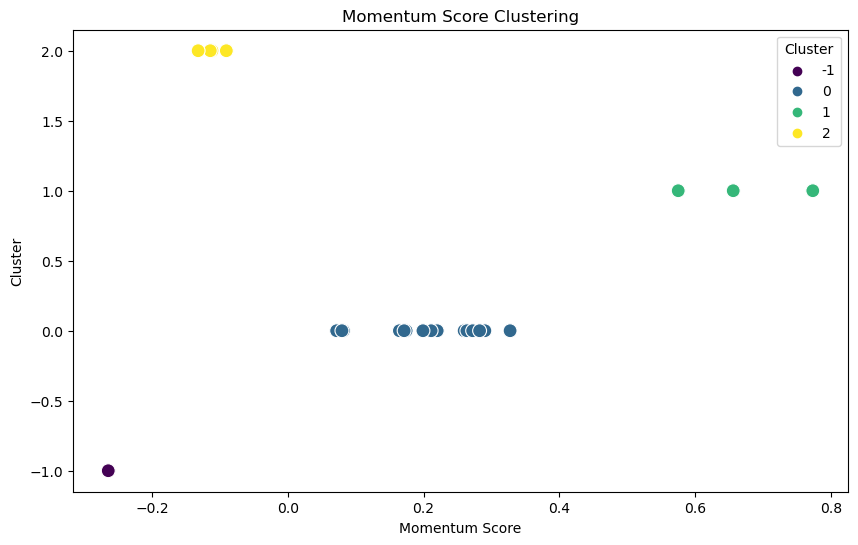

In [96]:
# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=momentum_df, x='MomentumScore', y='Cluster', hue='Cluster', palette='viridis', s=100)
plt.title('Momentum Score Clustering')
plt.xlabel('Momentum Score')
plt.ylabel('Cluster')
plt.legend(title='Cluster')
plt.show()

In [97]:
# Print grouped stocks by cluster
print("Stocks grouped by clusters:")
grouped_stocks = momentum_df.groupby('Cluster').apply(lambda x: list(x.index)).to_dict()

for cluster, stocks in grouped_stocks.items():
    print(f"Cluster {cluster}: {stocks}")

Stocks grouped by clusters:
Cluster -1: ['TEAM']
Cluster 0: ['ADSK', 'CTSH', 'AEP', 'AAPL', 'GOOGL', 'ADI', 'AZN', 'AMAT', 'ASML', 'GOOG', 'AMZN', 'CDW', 'BKNG', 'CDNS', 'AMGN']
Cluster 1: ['CRWD', 'COST', 'AVGO']
Cluster 2: ['CMCSA', 'CSGP', 'CSCO', 'CHTR']


In [98]:
# Strategy: Select top-performing stocks based on cluster
# Assuming higher momentum scores are better, adjust this logic as needed
top_cluster = momentum_df['Cluster'].mode()[0]  # Get the most common cluster
selected_stocks = momentum_df[momentum_df['Cluster'] == top_cluster].index.tolist()

print(f"Selected Stocks for Momentum Strategy: {selected_stocks}")

Selected Stocks for Momentum Strategy: ['ADSK', 'CTSH', 'AEP', 'AAPL', 'GOOGL', 'ADI', 'AZN', 'AMAT', 'ASML', 'GOOG', 'AMZN', 'CDW', 'BKNG', 'CDNS', 'AMGN']


In [99]:
def DBSCAN_analysis(eps, Returns, n_components='NA'):
  #feeding all changes
  if n_components == 'NA':
      X = Returns.transpose()
  else:
      pca = PCA(n_components=n_components)
      X = pca.fit(returns).components_.T

  clf = DBSCAN(eps=eps, min_samples=2)
  clf.fit(X)

  labels = clf.labels_

  n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
  print('cluster found: ', n_clusters_)
  clustered = clf.labels_
  clustered_series = pd.Series(index=returns.columns, data=clustered.flatten())
  clustered_series_all = pd.Series(index=returns.columns, data=clustered.flatten())
  clustered_series = clustered_series[clustered_series != -1]
  counts = clustered_series.value_counts()
  plt.barh(
  range(len(clustered_series.value_counts())),
  clustered_series.value_counts())
  plt.title('Cluster Member Counts')
  plt.xlabel('Stocks in Cluster')
  plt.ylabel('Cluster Number')
  plt.show()

  return labels, clustered_series_all, clustered_series

cluster found:  2


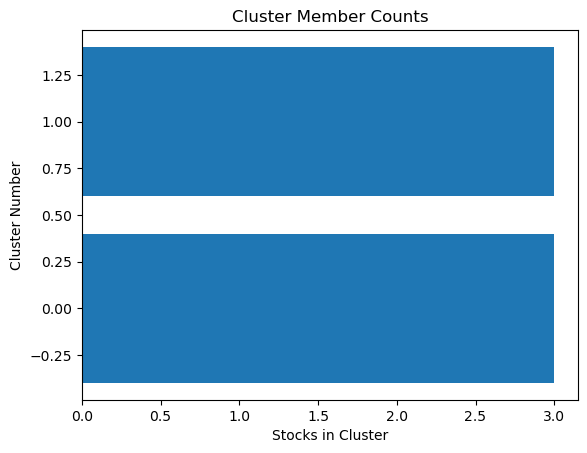

In [100]:
PCA_NUM = 3
labels, clustered_series_all, clustered_series = DBSCAN_analysis(eps=0.07,Returns = returns, n_components = PCA_NUM)

In [101]:
CLUSTER_SIZE_LIMIT = 9999
counts = clustered_series.value_counts()
ticker_count_reduced = counts[(counts>1) & (counts<=CLUSTER_SIZE_LIMIT)]
print ("Clusters formed: %d" % len(ticker_count_reduced))
print ( "Pairs to evaluate: %d" % (ticker_count_reduced*(ticker_count_reduced-1)).sum())

Clusters formed: 2
Pairs to evaluate: 12


In [102]:
def DBSCAN_plot(eps,Returns,n_components):

    if n_components == 'NA':
        X = Returns.transpose()
    else:
        pca = PCA(n_components=n_components)
        X = pca.fit(Returns).components_.T
    clf = DBSCAN(eps=eps, min_samples=2)
    clf.fit(X)
    labels = clf.labels_
    clustered = clf.labels_
    clustered_series = pd.Series(index=returns.columns, data=clustered.flatten())
    clustered_series_all = pd.Series(index=returns.columns, data=clustered.flatten())
    clustered_series = clustered_series[clustered_series != -1]
    counts = clustered_series.value_counts()

    # let's visualize some clusters
    cluster_vis_list = list(counts.index)[::-1]
    # plot a handful of the smallest clusters
    for clust in cluster_vis_list[0:len(cluster_vis_list)]:
        tickers = list(clustered_series[clustered_series==clust].index)
        #data = np.exp(np.log1p(returns[tickers]).cumsum())
        data = returns[tickers].cumsum()
        print(tickers)
       #means = np.log(returns[tickers].mean())
       # data = np.log(returns[tickers]).sub(means)
        data.plot(title='Stock Time Series for Cluster %d' % clust)
        plt.show()

['AMAT', 'ASML']


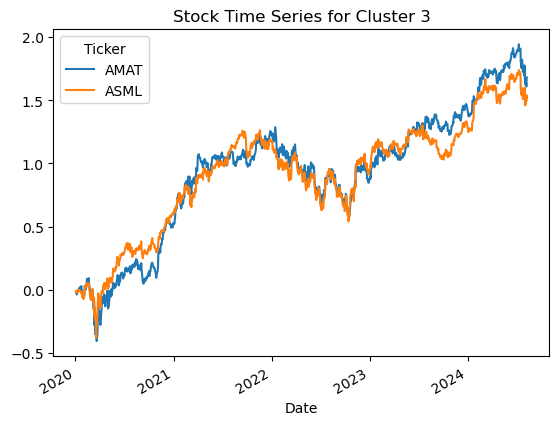

['ADSK', 'AMZN']


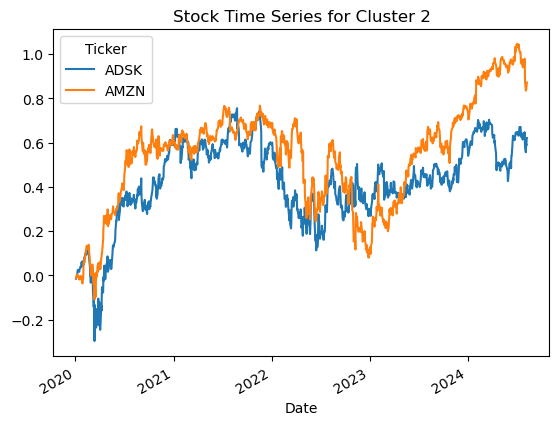

['ADI', 'AVGO']


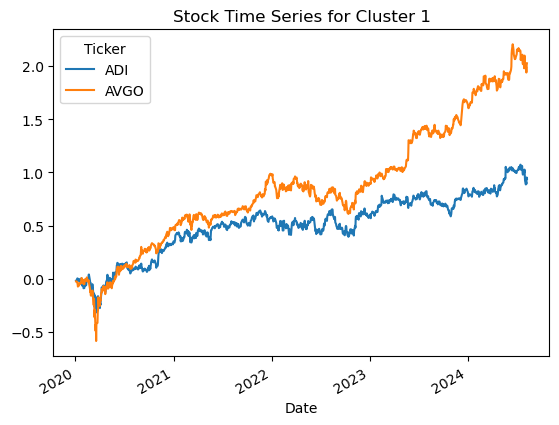

['AAPL', 'AEP', 'AMGN', 'AZN', 'CDW', 'CHTR', 'CMCSA', 'COST', 'CSCO', 'CSGP', 'CTSH', 'GOOG', 'GOOGL']


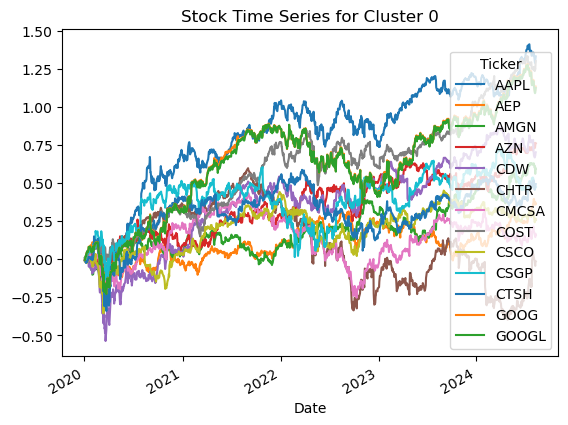

In [103]:
DBSCAN_plot(eps=0.15,Returns = returns, n_components = 4)

### 3. Compare with NASDAQ-100 performance

We don't have access to S&P 500 data but want to evaluate whether our selected stocks are outperforming the NASDAQ-100. 
We use the NASDAQ-100 ETF (like QQQ) as a Benchmark for comparison.

Hence we calculate the Benchmark Returns by downloading the historical adjusted closing prices for the NASDAQ-100 ETF (QQQ) and calculate its returns over the same period as our stocks.

We then compare Stock Returns to the Benchmark: Calculate the percentage change of each stock's adjusted closing price and compare it against the benchmark's percentage change. We then label each stock as outperforming or underperforming the NASDAQ-100.

In [106]:
# Download historical data for NASDAQ-100 ETF (QQQ) as a benchmark
benchmark_ticker = 'QQQ'
benchmark_data = yf.download(benchmark_ticker, start=start_date, end=end_date)['Adj Close']

[*********************100%%**********************]  1 of 1 completed


In [107]:
# Function to calculate stock and benchmark returns
def calculate_returns(stock_data, benchmark_data):
    stock_returns = stock_data.pct_change().dropna()
    benchmark_returns = benchmark_data.pct_change().dropna()

    # Align the returns by date (axis=0)
    stock_returns, benchmark_returns = stock_returns.align(benchmark_returns, join='inner', axis=0)
    
    return stock_returns, benchmark_returns

In [108]:
# Compare stock returns against the benchmark
def compare_to_benchmark(stock_returns, benchmark_returns, threshold=0.02):
    # Initialize DataFrames to hold outperformance and underperformance
    outperformance = pd.DataFrame(index=stock_returns.index, columns=stock_returns.columns)
    underperformance = pd.DataFrame(index=stock_returns.index, columns=stock_returns.columns)
    
    # Compare each stock's returns to the benchmark
    for column in stock_returns.columns:
        outperformance[column] = stock_returns[column] > (benchmark_returns + threshold)
        underperformance[column] = stock_returns[column] < (benchmark_returns - threshold)
    
    return outperformance, underperformance

In [109]:
# Function to build dataset for training
def build_dataset(stock_data, benchmark_data):
    stock_returns, benchmark_returns = calculate_returns(stock_data, benchmark_data)

    X = stock_returns.values
    y, z = compare_to_benchmark(stock_returns, benchmark_returns)

    return X, y.values, z.values

In [110]:
def train_models(X_train, y_train, z_train):
    clf_outperf = RandomForestClassifier(n_estimators=100)
    clf_underperf = RandomForestClassifier(n_estimators=100)
    
    # Check lengths before fitting
    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)
    print("z_train shape:", z_train.shape)
    
    # Ensure X_train, y_train, and z_train have consistent lengths
    if len(X_train) == len(y_train) == len(z_train):
        clf_outperf.fit(X_train, y_train)
        clf_underperf.fit(X_train, z_train)
    else:
        raise ValueError("Inconsistent lengths of X_train, y_train, and z_train")
    
    return clf_outperf, clf_underperf

# Example data (replace these with your actual data)
X = np.random.rand(1000, 22)  # Features
y = np.random.randint(0, 2, 1000)  # Labels for outperformance
z = np.random.randint(0, 2, 1000)  # Labels for underperformance

# Split data consistently: Use the same split indices for y and z
X_train, X_test, y_train, y_test, z_train, z_test = train_test_split(X, y, z, test_size=0.3, random_state=42)

# Train the models
clf_outperf, clf_underperf = train_models(X_train, y_train, z_train)

# Validate the models on the test data
y_pred_outperf = clf_outperf.predict(X_test)
y_pred_underperf = clf_underperf.predict(X_test)

X_train shape: (700, 22)
y_train shape: (700,)
z_train shape: (700,)


In [111]:
# Get stock data for the selected stocks and drop columns with any NaN values
stock_data = yf.download(portfolio_B["Stock"].tolist(), start=start_date, end=end_date)['Adj Close'].dropna(axis=1)

# Build dataset and train models
X, y, z = build_dataset(stock_data, benchmark_data)

# Split the dataset into training and test sets (e.g., 80% train, 20% test)
assert len(y) == len(X), "X and y must have the same number of samples"
assert len(z) == len(X), "X and z must have the same number of samples"

# Proceed with train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
_, _, z_train, z_test = train_test_split(X, z, test_size=0.3, random_state=42)

# Train the models
clf_outperf, clf_underperf = train_models(X_train, y_train, z_train)

# Validate the models on the test data
y_pred_outperf = clf_outperf.predict(X_test)
y_pred_underperf = clf_underperf.predict(X_test)

# Calculate accuracy for validation
outperf_accuracy = accuracy_score(y_test, y_pred_outperf)
underperf_accuracy = accuracy_score(z_test, y_pred_underperf)

print(f"Outperformance Model Accuracy: {outperf_accuracy:.2f}")
print(f"Underperformance Model Accuracy: {underperf_accuracy:.2f}")

[*********************100%%**********************]  26 of 26 completed


X_train shape: (805, 23)
y_train shape: (805, 23)
z_train shape: (805, 23)
Outperformance Model Accuracy: 0.37
Underperformance Model Accuracy: 0.36


The below code attempts to use the above model to make predictions on the entire data set. The intent is to isolate the underperforming stocks from the overperforming stocks and make a strategy tied to this.

At the time of posting the rendering of the plot for this was still being debugged.

# Predict on the full dataset
y_pred_full_outperf = clf_outperf.predict(X)
y_pred_full_underperf = clf_underperf.predict(X)

# Ensure the predictions are 1-dimensional
y_pred_full_outperf = y_pred_full_outperf.flatten()
y_pred_full_underperf = y_pred_full_underperf.flatten()

# Store stock_data in a new variable for manipulation
stock_data_temp = stock_data.copy()

# Ensure stock_data_temp has the same length as predictions
min_length = min(len(y_pred_full_outperf), len(stock_data_temp), len(X))

# Truncate predictions, stock_data_temp, and X to the minimum length
y_pred_full_outperf = y_pred_full_outperf[:min_length]
y_pred_full_underperf = y_pred_full_underperf[:min_length]
stock_data_temp = stock_data_temp.iloc[:min_length]
X = X[:min_length]  # Use array slicing since X is a numpy array

# Now that they are of equal length, align the index
stock_data_temp.index = X.index

# Convert predictions to DataFrames with the adjusted index
outperformance = pd.DataFrame(y_pred_full_outperf, index=stock_data_temp.index, columns=['Outperformance'])
underperformance = pd.DataFrame(y_pred_full_underperf, index=stock_data_temp.index, columns=['Underperformance'])

# Verify the DataFrames
print("Outperformance DataFrame:")
print(outperformance.head())

print("Underperformance DataFrame:")
print(underperformance.head())

# Print sums
print("Sum of outperformance by stock:")
print(outperformance.sum())

print("Sum of underperformance by stock:")
print(underperformance.sum())

# Identify the overperforming and underperforming stocks
overperforming_stocks = outperformance[outperformance['Outperformance'] > 0].index
underperforming_stocks = underperformance[underperformance['Underperformance'] > 0].index

# Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Plot overperforming stocks
plt.subplot(1, 2, 1)
if len(overperforming_stocks) > 0:
    for stock in overperforming_stocks:
        plt.plot(stock_data_temp.loc[stock].pct_change().cumsum(), label=stock)
    plt.title("Overperforming Stocks vs Benchmark")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Returns")
    plt.legend()
else:
    plt.title("No Overperforming Stocks Found")

# Plot underperforming stocks
plt.subplot(1, 2, 2)
if len(underperforming_stocks) > 0:
    for stock in underperforming_stocks:
        plt.plot(stock_data_temp.loc[stock].pct_change().cumsum(), label=stock)
    plt.title("Underperforming Stocks vs Benchmark")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Returns")
    plt.legend()
else:
    plt.title("No Underperforming Stocks Found")

plt.tight_layout()
plt.show()


In [114]:
def backtestMetrics(stocks, returns, performance_criteria):
    # Initialize a DataFrame to store performance metrics
    performance_metrics = pd.DataFrame(index=stocks, columns=['Cumulative Return', 'Annualized Return', 'Volatility', 'Sharpe Ratio'])
    
    for stock in stocks:
        stock_returns = returns[stock]
        
        # Example metrics calculation
        cumulative_returns = (1 + stock_returns).prod() - 1
        annualized_return = (1 + cumulative_returns) ** (252 / len(stock_returns)) - 1
        volatility = stock_returns.std() * np.sqrt(252)
        sharpe_ratio = annualized_return / volatility if volatility != 0 else np.nan
        
        # Assign metrics to DataFrame
        performance_metrics.loc[stock] = {
            'Cumulative Return': cumulative_returns,
            'Annualized Return': annualized_return,
            'Volatility': volatility,
            'Sharpe Ratio': sharpe_ratio
        }
    
    # Apply performance criteria
    overperforming_stocks = performance_metrics[
        (performance_metrics['Annualized Return'] > performance_criteria['min_annualized_return']) &
        (performance_metrics['Sharpe Ratio'] > performance_criteria['min_sharpe_ratio'])
    ]
    
    # Return the list of overperforming stocks
    return overperforming_stocks.index.tolist()

# Use the function to select stocks
stocks = high_growth_stocks

if isinstance(stocks, np.ndarray):
    stocks = stocks.tolist()

# Fetch price data
price_data = fetch_data(stocks, start_date, end_date)

# Calculate daily returns
returns = calculate_returns(price_data)

performance_criteria = {
    'min_annualized_return': 0.15,  # 15% annualized return
    'min_sharpe_ratio': 1.0         # Sharpe ratio greater than 1.0
}

# Assume `returns` DataFrame is already defined
overperforming_stocks = backtestMetrics(stocks, returns, performance_criteria)
print("Overperforming Stocks:", overperforming_stocks)


NameError: name 'fetch_data' is not defined

## V Reinforcement Learning

Below is an oversimplified example of how you might apply RL to stock trading using a Q-Learning approach. Q-Learning is a model-free RL algorithm used to find the optimal action-selection policy for a given finite Markov decision process.

### 1. Create a custom trading environment

In [ ]:
# Reinitialize stock_data
stock_data = yf.download(instrumentIds, start=start_date, end=end_date)

In [ ]:
class StockTradingEnv(gym.Env):
    def __init__(self, data):
        super(StockTradingEnv, self).__init__()
        self.data = data
        self.current_step = 0
        self.max_steps = len(data) - 1
        
        # Action space: Buy, Hold, Sell
        self.action_space = spaces.Discrete(3)
        
        # Observation space: Current price and previous price
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(2,), dtype=np.float32)

    def reset(self):
        self.current_step = 0
        self.done = False
        return self._get_observation()

    def _get_observation(self):
        return np.array([
            self.data['Adj Close'].iloc[self.current_step],
            self.data['Adj Close'].iloc[self.current_step - 1] if self.current_step > 0 else self.data['Close'].iloc[self.current_step]
        ])

    def step(self, action):
        self.current_step += 1
        if self.current_step >= len(self.data) - 1:
            self.done = True
        
        reward = 0
        if action == 0:  # Buy
            reward = self.data['Adj Close'].iloc[self.current_step] - self.data['Adj Close'].iloc[self.current_step - 1]
        elif action == 1:  # Hold
            reward = 0
        elif action == 2:  # Sell
            reward = self.data['Adj Close'].iloc[self.current_step - 1] - self.data['Adj Close'].iloc[self.current_step]
        
        return self._get_observation(), reward, self.done, {}

    def render(self, mode='human'):
        pass



# Example usage with stock_data
env = StockTradingEnv(stock_data)

# Example to verify the data
print(env.reset())  # Initial state
print(env.step(1))  # Example step with action 1 (Buy)

### 2. Implement Q-learning

In [ ]:
class QLearning:
    def __init__(self, action_space, state_space_size, learning_rate=0.1, discount_factor=0.9, exploration_rate=1.0, exploration_decay=0.995):
        self.q_table = np.zeros((state_space_size, action_space))
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate
        self.exploration_decay = exploration_decay

    def select_action(self, state_index):
        if np.random.rand() < self.exploration_rate:
            return np.random.choice([0, 1, 2])  # Explore
        else:
            return np.argmax(self.q_table[state_index])  # Exploit

    def update_q_table(self, state_index, action, reward, next_state_index):
        best_next_action = np.argmax(self.q_table[next_state_index])
        td_target = reward + self.discount_factor * self.q_table[next_state_index][best_next_action]
        td_error = td_target - self.q_table[state_index][action]
        self.q_table[state_index][action] += self.learning_rate * td_error

    def decay_exploration(self):
        self.exploration_rate *= self.exploration_decay


### 3. Train the model

In [ ]:
data = stock_data

# Initialize environment and Q-learning agent
env = StockTradingEnv(data)
state_space_size = 100  # Define a fixed size for state space, e.g., the number of discrete states
action_space = env.action_space.n
q_learning = QLearning(action_space, state_space_size)

# Training loop
num_episodes = 1000
for episode in range(num_episodes):
    state = env.reset()
    
    # Get the first element of the state array and ensure it's a scalar
    state_value = state[0]  # This is the first element of the observation

    # Convert to a scalar integer for indexing
    if isinstance(state_value, pd.Series):
        state_value = state_value.iloc[0]
    state_index = int(np.floor(state_value))
    total_reward = 0
    
    while True:
        action = q_learning.select_action(state_index)
        next_state, reward, done, _ = env.step(action)
        
        # Handle next_state similarly
        next_state_value = next_state[0]
        if isinstance(next_state_value, pd.Series):
            next_state_value = next_state_value.iloc[0]
        next_state_index = int(np.floor(next_state_value))

        # Update Q-table using integer indices
        q_learning.update_q_table(state_index, action, reward, next_state_index)
        state_index = next_state_index
        total_reward += reward
        
        if done:
            break
    
    q_learning.decay_exploration()
    print(f"Episode {episode+1}: Total Reward: {total_reward}")

print("Training completed.")


### 4. Evaluate model

In [ ]:
def state_to_index(state):
    # Example function to convert state to an index
    # This needs to match the way states are represented and indexed in your Q-table
    return int(np.floor(state[0]))  # Adjust this function as needed

def evaluate_model(env, q_learning, num_episodes=100):
    total_rewards = []
    for episode in range(num_episodes):
        state = env.reset()
        state_index = state_to_index(state)  # Convert state to index
        total_reward = 0
        
        done = False
        while not done:
            action = np.argmax(q_learning.q_table[state_index])  # Select action based on Q-table
            next_state, reward, done, _ = env.step(action)
            next_state_index = state_to_index(next_state)  # Convert next state to index
            
            state_index = next_state_index
            total_reward += reward
        
        total_rewards.append(total_reward)
    
    avg_reward = np.mean(total_rewards)
    print(f"Average Reward over {num_episodes} episodes: {avg_reward}")

# Example evaluation
evaluate_model(env, q_learning)
